# Aged Mouse Analysis 
## Dataset: Takasugi et al. Nature, 2024 

### Alex Maropakis
05-18-2026: Added helper functions for plotting and statistics 

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy.odr import Model, RealData, ODR
from scipy.stats import (
    gaussian_kde,
    ttest_ind,
    fisher_exact,
    kruskal,
    mannwhitneyu
)
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg

print("packages have been successfully read in!")

packages have been successfully read in!


In [2]:
#Setting directories and reading in data 
#Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample 

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
PROJ_DIR     = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/Takasugi_2024/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Takasugi_2024/'
DEPDIR          = CODE_DIR + 'Dependencies/Takasugi_2024/'
MQ_DIR          = PROJ_DIR + 'mq_output/Takasugi_2024/'
PLOT_DIR        = PROJ_DIR + 'Plots/Takasugi_2024/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

#S1 AORTA
aorta_proj_dir      = OUTDIR + 'Aorta/'
aorta_aa_subs_dir   = INDIR + 'Aorta/'
aorta_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_aorta.xlsx')
aorta_samples       = ['S'+str(i) for i in list(set(aorta_sample_map['TMT plex']))]
aorta_mq            = MQ_DIR + 'Aorta/'

#S2 BRAIN 
brain_proj_dir      = OUTDIR + 'Brain/'
brain_aa_subs_dir   = INDIR + 'Brain/'
brain_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_brain.xlsx')
brain_samples       = ['S'+str(i) for i in list(set(brain_sample_map['TMT plex']))]
brain_mq            = MQ_DIR + 'Brain/'

#S3 HEART
heart_proj_dir      = OUTDIR + 'Heart/'
heart_aa_subs_dir   = INDIR + 'Heart/'
heart_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_heart.xlsx')
heart_samples       = ['S'+str(i) for i in list(set(heart_sample_map['TMT plex']))]
heart_mq            = MQ_DIR + 'Heart/'

#S4 KIDNEY
kidney_proj_dir      = OUTDIR + 'Kidney/'
kidney_aa_subs_dir   = INDIR + 'Kidney/'
kidney_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_kidney.xlsx')
kidney_samples       = ['S'+str(i) for i in list(set(kidney_sample_map['TMT plex']))]
kidney_mq            = MQ_DIR + 'Kidney/'

#S5 LIVER
liver_proj_dir      = OUTDIR + 'Liver/'
liver_aa_subs_dir   = INDIR + 'Liver/'
liver_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_liver.xlsx')
liver_samples       = ['S'+str(i) for i in list(set(liver_sample_map['TMT plex']))]
liver_mq            = MQ_DIR + 'Liver/'

#S6 LUNG
# lung_proj_dir      = OUTDIR + 'Lung/'
# lung_aa_subs_dir   = INDIR + 'Lung/'
# lung_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_lung.xlsx')
# lung_samples       = ['S'+str(i) for i in list(set(lung_sample_map['TMT plex']))]
# lung_mq            = MQ_DIR + 'Lung/'

#S7 MUSCLE
muscle_proj_dir      = OUTDIR + 'Muscle/'
muscle_aa_subs_dir   = INDIR + 'Muscle/'
muscle_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_muscle.xlsx')
muscle_samples       = ['S'+str(i) for i in list(set(muscle_sample_map['TMT plex']))]
muscle_mq            = MQ_DIR + 'Muscle/'

#S8 SKIN
skin_proj_dir      = OUTDIR + 'Skin/'
skin_aa_subs_dir   = INDIR + 'Skin/'
skin_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_skin.xlsx')
skin_samples       = ['S'+str(i) for i in list(set(skin_sample_map['TMT plex']))]
skin_mq            = MQ_DIR + 'Skin/'

#lists to quickly index dataset-specific sample maps from just the dataset name

## lists with lung tissue added 
# datasets = ['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin']
# data_dir_list = [aorta_aa_subs_dir, brain_aa_subs_dir, heart_aa_subs_dir, kidney_aa_subs_dir, liver_aa_subs_dir, lung_aa_subs_dir, muscle_aa_subs_dir, skin_aa_subs_dir]
# samples_list = [aorta_samples, brain_samples, heart_samples, kidney_samples, liver_samples, lung_samples, muscle_samples, skin_samples]
# sample_map_list = [aorta_sample_map, brain_sample_map, heart_sample_map, kidney_sample_map, liver_sample_map, lung_sample_map, muscle_sample_map, skin_sample_map]
# proj_dir_list = [aorta_proj_dir, brain_proj_dir, heart_proj_dir, kidney_proj_dir, liver_proj_dir, lung_proj_dir, muscle_proj_dir, skin_proj_dir]
# mq_dir_list = [aorta_mq, brain_mq, heart_mq, kidney_mq, liver_mq, lung_mq, muscle_mq, skin_mq]

datasets = ['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Muscle', 'Skin']
data_dir_list = [aorta_aa_subs_dir, brain_aa_subs_dir, heart_aa_subs_dir, kidney_aa_subs_dir, liver_aa_subs_dir, muscle_aa_subs_dir, skin_aa_subs_dir]
samples_list = [aorta_samples, brain_samples, heart_samples, kidney_samples, liver_samples, muscle_samples, skin_samples]
sample_map_list = [aorta_sample_map, brain_sample_map, heart_sample_map, kidney_sample_map, liver_sample_map, muscle_sample_map, skin_sample_map]
proj_dir_list = [aorta_proj_dir, brain_proj_dir, heart_proj_dir, kidney_proj_dir, liver_proj_dir, muscle_proj_dir, skin_proj_dir]
mq_dir_list = [aorta_mq, brain_mq, heart_mq, kidney_mq, liver_mq, muscle_mq, skin_mq]


print("directories loaded successfully!")

loading directories...
directories loaded successfully!


In [3]:
""" 
Read in data generated from dependencies code
if dependencies have not been generated, go back and generate
""" 

pos_prob_df = pd.read_csv(DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)
print(pos_prob_df)
frag_dict = pickle.load(open(DEPDIR+'Fragment_ion_dict.p', 'rb')) ### keys of frag_dict refer to the index in pos_prob_df
print(frag_dict)

SAAP_quant_df = pd.read_excel(DEPDIR+'SAAP_precursor_reporter_quant_data.xlsx', index_col=0)
#SAAP_precursor_reporter_quant_data.xlsx contains both precursor and reporter ion data for validated SAAPs
print(SAAP_quant_df)
SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

                              SAAP                             BP     AAS  \
0                        SALSGLLHR                      AALSGLLHR  A to S   
1                        SALSGLLHR                      AALSGLLHR  A to S   
2                      TRLEQEITTYR                    TRLEQEIATYR  A to T   
3                         PATVSLPR                       VATVSLPR  V to P   
4                    LTWIRPQPGEGER                  LPWIRPQPGEGER  P to T   
..                             ...                            ...     ...   
183   ETTWHGQGQDQGQGPSQESAAEQGAVEK   ETPWHGQGQDQGQGPSQESAAEQGAVEK  P to T   
184  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ  P to T   
185        DNLTLWNSDTQGDEAEAGEGGEN        DNLTLWTSDTQGDEAEAGEGGEN  T to N   
186            DSTYSMSSLLTLTKDEYER            DSTYSMSSTLTLTKDEYER  T to L   
187            LYTWGVVEVENPEHNDFLK            LYPWGVVEVENPEHNDFLK  P to T   

     AAS index  Positional probability  charge TMT set Dataset  \
0        

In [4]:
# retain only SAAP observations with 100% data completeness across all columns
SAAP_quant_complete_df=SAAP_quant_df.dropna()
print(f'{len(SAAP_quant_complete_df):,} fully complete SAAP observations retained')
print(f'{100*(len(SAAP_quant_complete_df)/len(SAAP_quant_df)):.2f}% dataset completeness')
SAAP_quant_df = SAAP_quant_complete_df # replace read-in SAAP_quant_df with filtered version with complete data for downstream analyses

## if wanting SAAP_quant_df with missing values, skip this step and use original SAAP_quant_df read in from file above
# SAAP_quant_df = pd.read_excel(DEPDIR+'SAAP_precursor_reporter_quant_data.xlsx', index_col=0)
# #SAAP_precursor_reporter_quant_data.xlsx contains both precursor and reporter ion data for validated SAAPs
# print(SAAP_quant_df)
# SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

19,712 fully complete SAAP observations retained
92.56% dataset completeness


# Helper Functions

## Data Processing

In [5]:
def get_filter_df(data_dir, samples):
    """ 
    function that reads in output from decode pipeline to get number of peptides in each category
    Input: directory with output files for dataset, dataset samples/TMT set names
    output: dataframe with the number of peptides in each category
    """
    dp_ev_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p', 'rb'))
    dp_dict = pickle.load(open(data_dir+'DP_dict.p', 'rb'))
    mtp_dict = pickle.load(open(data_dir+'MTP_dict.p', 'rb'))
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb')) # dictionary of putative substitutions that pass FDR correction
    substr_dict = pickle.load(open(data_dir+'genome_substr_dict.p', 'rb'))
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    
    rows = []
    for s in samples:
        seqs = [[x for y in list(mtp_dict[s]['mistranslated sequence'].values()) for x in y] for s in samples]
        seqs = [x for y in seqs for x in y]
        if 'all_6frame_seqs' in substr_dict.keys():
            homolog_seqs = substr_dict['all_6frame_seqs']
        else:
            homolog_seqs = substr_dict['all_frame6_seqs']
        seqs_hom = [x for x in seqs if x in homolog_seqs]
        
        n_main = len(dp_ev_dict[s]['Raw file'])
        n_dp = len(dp_dict[s]['Raw file'])
        n_ptm = len(ptm_dict[s]['Raw file'])
        n_aas = len(mtp_dict[s]['Raw file'])
        n_nohom = len([i for i,x in mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_hc = len([i for i,x in hc_mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_val = len(val_mtp_dict[s]['Raw file'])

        rows.append([s, n_main, n_dp, n_ptm, n_aas, n_nohom, n_hc, n_val])
    df = pd.DataFrame(rows, columns=['TMT set', 'Main peptides', 'DP', 'PTM', 'AAS', 'Non-homologous', 'High-confidence', 'Validated'])

    return(df)

In [6]:
# plotting PTMs found
def get_ptm_df(ptm_dict, ds):
    """
    function to get a dataframe of PTMS x datasets from the datasets' PTM_dict.p
    """
    master_ptm_list = []
    for s,v in ptm_dict.items():
        s_ptm_dict = v['PTM']
        for ptm_list in s_ptm_dict.values():
            new_ptm_list = [x for x in ptm_list if x not in master_ptm_list]
            new_ptm_list = list(set(new_ptm_list))
            master_ptm_list = master_ptm_list + new_ptm_list

    heatmap_df = pd.DataFrame(index=master_ptm_list, columns=list(range(1,24)))
    for s, v in ptm_dict.items():
        if ds !='Healthy':
            s_int = int(s[1:])
        else:
            s_int=s
        ptm_list = list(v['PTM'].values())
        ptm_list = [x for y in ptm_list for x in y]
        ptm_count = Counter(ptm_list)
        for ptm, count in ptm_count.items():
            heatmap_df.loc[ptm, s_int] = count
            #heatmap_df.loc[ptm, s_int] = np.log10(count)
    heatmap_df.fillna(0, inplace=True)
    return(heatmap_df)

In [7]:
# functions to get number of unique candidate substituted peptides and number of unique validated substituted peptides for each sample in each dataset
def get_n_unq_seqs(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique candidate substituted peptides
    """
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    s_seqs = [x for y in hc_mtp_dict[s]['mistranslated sequence'].values() for x in y]
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

def get_n_unq_val(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique validated substituted peptides
    """
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p', 'rb'))
    s_seqs = list(val_mtp_dict[s]['mistranslated sequence'].values())
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

In [ ]:
# functions to process data for substitution-level analysis 
raas_col = 'Reporter_RAAS' # tmt level RAAS column to use for grouping
age_order = ['t06mo', 't15mo', 't24mo', 't30mo'] # 4 age groups 
replicates = [1, 2, 3, 4] # 4 mice per age group 
aa_order = [ # amino acid ordering for standardized plotting
    'G', 'A', 'V', 'L', 'I', 'M', 'P',
    'F', 'Y', 'W',
    'S', 'T', 'C', 'N', 'Q',
    'D', 'E',
    'K', 'R', 'H'
]

def replicate_cols(df):
    # add replicate columns to dataframe based on TMT set and age group
    saap_df = df.copy()
    saap_df['Age'] = saap_df['Sample Type']
    saap_df['Tissue'] = saap_df['Dataset']
    saap_df['Replicate'] = saap_df['Sample'].str.extract(r'_rep(\d+)_', expand=False)
    saap_df['Replicate'] = pd.to_numeric(saap_df['Replicate'], errors='coerce')
    return saap_df

def top_sub_order(df, n=15):
    # get top n most frequent substituted amino acids for standardized plotting order
    return df['aa_sub'].value_counts().head(n).index

## Figure Formatting & Plotting

In [9]:
# Functions for figure formatting
class GridShader():
    """
    function used to create alternating vertical gray and white background in plots
    """
    def __init__(self, ax, first=True, **kwargs):
        self.spans = []
        self.sf = first
        self.ax = ax
        self.kw = kwargs
        self.ax.autoscale(False, axis="x")
        self.cid = self.ax.callbacks.connect('xlim_changed', self.shade)
        self.shade()
    def clear(self):
        for span in self.spans:
            try:
                span.remove()
            except:
                pass
    def shade(self, evt=None):
        self.clear()
        xticks = self.ax.get_xticks()
        xlim = self.ax.get_xlim()
        xticks = xticks[(xticks > xlim[0]) & (xticks < xlim[-1])]
        locs = np.concatenate(([[xlim[0]], xticks, [xlim[-1]]]))

        start = [x-0.5 for x in locs[1-int(self.sf)::2]]
        end = [x-0.5 for x in locs[2-int(self.sf)::2]]

        for s, e in zip(start, end):
            self.spans.append(self.ax.axvspan(s, e, zorder=0, **self.kw))


def bihist(y1, y2, nbins=10, h=None):
    '''
    Function used to create violin plots as bihistograms with no smoothing.
    h is an axis handle. If not present, a new figure is created.
    '''
    if h is None: h = plt.figure().add_subplot(111)
    ymin = np.floor(np.minimum(min(y1), min(y2)))
    ymax = np.ceil(np.maximum(max(y1), max(y2)))
    bins = np.linspace(ymin, ymax, nbins)
    n1, bins1, patch1 = h.hist(y1, bins, orientation='horizontal', color='#aaaaaa', edgecolor=None, linewidth=0,rwidth=1)
    n2, bins2, patch2 = h.hist(y2, bins, orientation='horizontal', color='#aaaaaa', edgecolor=None, linewidth=0,rwidth=1)
    # set xmax:
    xmax = 0
    for i in patch1:
        i.set_edgecolor(None)
        width = i.get_width()
        if width > xmax: xmax = width
    # invert second histogram and set xmin:
    xmin = 0
    for i in patch2:
        i.set_edgecolor(None)
        width = i.get_width()
        width = -width
        i.set_width(width)
        if width < xmin: xmin = width
    h.set_xlim(xmin*1.1, xmax*1.1)          
    h.figure.canvas.draw()

## Statistics

In [35]:
def run_fdr(df, p_col='pval', out_col='FDR'):
    """Apply BH-FDR correction while preserving NaN p-values."""
    df[out_col] = np.nan
    valid_pvals = df[p_col].notna()

    if valid_pvals.any():
        df.loc[valid_pvals, out_col] = multipletests(
            df.loc[valid_pvals, p_col],
            method='fdr_bh'
        )[1]

    return df

def add_sig_label(df, fdr_col='FDR'):
    """Convert FDR thresholds to plotting/reporting labels."""
    df['Significance'] = 'ns'
    df.loc[df[fdr_col] < 0.05, 'Significance'] = '*'
    df.loc[df[fdr_col] < 0.01, 'Significance'] = '**'
    df.loc[df[fdr_col] < 0.001, 'Significance'] = '***'
    return df

# 1. SAAP Detection & QC

## Dataset Metrics

Aorta 16
Brain 16
Heart 16
Kidney 16
Liver 16
Muscle 16
Skin 16
112
Aorta
Brain
Heart
Kidney
Liver
Muscle
Skin
{'Main peptides': np.int64(508497), 'DP': np.int64(120106), 'PTM': np.int64(40984), 'AAS': np.int64(3739), 'Non-homologous': np.int64(3739), 'High-confidence': np.int64(3410), 'Validated': np.int64(1760)}


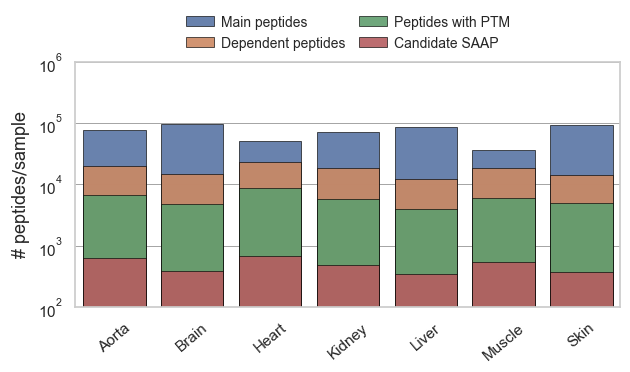

In [10]:
# N peptide IDs through filtering steps
# get number of samples in each dataset
n_samples_data = []
total = 0
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    samples = sample_map['sample_name'].values

    n_samples = len(samples)
    total += n_samples
    n_samples_data.append([ds, n_samples])
    print(ds, n_samples)
print(total)
n_samples_df = pd.DataFrame(n_samples_data, columns=['Dataset', 'N samples'])
n_samples_df.to_excel(OUTDIR+'N_samples_in_datasets.xlsx')

# create a dictionary containing the dataframes generated with the above function for each dataset
filter_dict = {}
for ds in datasets:
    print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    filter_dict[ds] = get_filter_df(data_dir, samples)

for ds in datasets:
    filter_dict[ds]['Dataset'] = [ds]*len(filter_dict[ds])
pickle.dump(filter_dict, open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'wb'))

#filter_dict = pickle.load(open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))
all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set', 'Dataset', 'Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
        
print(sum_dict)

# filtering modified peptides to candidate SAAP
barplot_rows = []
for i, row in all_df.iterrows():
    barplot_rows.append([row['Dataset'], row['Main peptides'], 'Main peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['DP'], 'Dependent peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['PTM'], 'Peptides with PTM', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['High-confidence'], 'Candidate SAAP', row['TMT set']])

barplot_df = pd.DataFrame(barplot_rows, columns=['Dataset', 'N peptide IDs', 'Peptide type', 'TMT set'])

plt.figure(figsize=(6.5, 4))
sns.set(style='whitegrid', context='notebook', font_scale=1.1)
ax = sns.barplot(
    data=barplot_df, 
    x='Dataset', 
    y='N peptide IDs', 
    hue='Peptide type', 
    dodge=False, 
    edgecolor='black', 
    linewidth=0.5, 
    alpha=0.9
)

ax.set_yscale('log')
ax.set_ylim([100, 1e6])
ax.set_ylabel('# peptides$/$sample', fontsize=13)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=40, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

ax.grid(True, axis='y', linestyle='solid', linewidth=0.5, color='gray')
ax.grid(False, axis='x')

handles, labels = ax.get_legend_handles_labels()
new_labels = ['Main peptides', 'Dependent peptides', 'Peptides with PTM', 'Candidate SAAP']
ax.legend(
    handles=handles,
    labels=new_labels,
    title='',
    bbox_to_anchor=(0.5, 1.12),
    loc='center',
    ncol=2,
    fontsize=10,
    handletextpad=0.5,
    columnspacing=1,
    frameon=False
)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'Dataset_filtering_barplot.pdf', bbox_inches='tight')
plt.show()

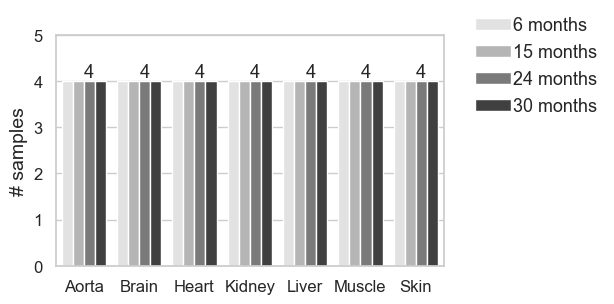

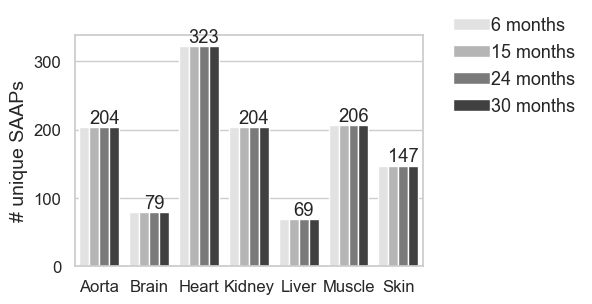

In [11]:
# N samples per dataset and age and plot 
plot_rows = []
plot_cols = ['Dataset', 'N samples', 'Sample type']
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    n_t6_samples = len(sample_map.loc[sample_map['Group']=='t06mo'])
    n_t15_samples = len(sample_map.loc[sample_map['Group']=='t15mo'])
    n_t24_samples = len(sample_map.loc[sample_map['Group']=='t24mo'])
    n_t30_samples = len(sample_map.loc[sample_map['Group']=='t30mo'])
    plot_rows.append([ds, n_t6_samples, '6 months'])
    plot_rows.append([ds, n_t15_samples, '15 months'])
    plot_rows.append([ds, n_t24_samples, '24 months'])
    plot_rows.append([ds, n_t30_samples, '30 months'])

plot_df = pd.DataFrame(plot_rows, columns=plot_cols)
sns.set_style('whitegrid')
fig,ax = plt.subplots(figsize=(5,3))
sns.barplot(data=plot_df, x='Dataset', y='N samples', hue='Sample type', palette=sns.color_palette(palette='Greys', n_colors=4))
ax.tick_params('both', labelsize=12)
plt.xlabel('')
plt.ylabel('# samples', fontsize=14)
plt.ylim([0,5])
plt.bar_label(plt.gca().containers[2])
plt.legend(ncol=1, bbox_to_anchor=(1.04,1.15), frameon=False, fontsize=13, handletextpad=0.1)
plt.savefig(PLOT_DIR+'AgedMouse_N_samples_per_dataset.pdf', bbox_inches='tight')

# N SAAPs per dataset and age and plot
plot_rows=[]
plot_cols=['Dataset','N SAAPs','Sample type']

for ds in datasets:
    ds_df=SAAP_quant_df[SAAP_quant_df['Dataset']==ds]

    n_t6=ds_df.loc[ds_df['Sample Type']=='t06mo','MTP_seq'].nunique()
    n_t15=ds_df.loc[ds_df['Sample Type']=='t15mo','MTP_seq'].nunique()
    n_t24=ds_df.loc[ds_df['Sample Type']=='t24mo','MTP_seq'].nunique()
    n_t30=ds_df.loc[ds_df['Sample Type']=='t30mo','MTP_seq'].nunique()

    plot_rows.append([ds,n_t6,'6 months'])
    plot_rows.append([ds,n_t15,'15 months'])
    plot_rows.append([ds,n_t24,'24 months'])
    plot_rows.append([ds,n_t30,'30 months'])

plot_df=pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('whitegrid')
fig,ax=plt.subplots(figsize=(4.5,3))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Sample type',palette=sns.color_palette(palette='Greys',n_colors=4))
ax.tick_params('both',labelsize=12)
plt.xlabel('')
plt.ylabel('# unique SAAPs',fontsize=14)
plt.bar_label(plt.gca().containers[2])

plt.legend(ncol=1,bbox_to_anchor=(1.04,1.15),frameon=False,fontsize=13,handletextpad=0.1)
plt.savefig(PLOT_DIR+'AgedMouse_N_SAAPs_per_dataset.pdf',bbox_inches='tight')

In [12]:
# N peptides detected per dataset and age from MaxQuant evidence.txt
plot_rows=[]
plot_cols=['Dataset','N peptides','Sample type']
for i,ds in enumerate(datasets):
    evidence_df=pd.read_csv(mq_dir_list[i]+'combined/txt/evidence.txt', sep='\t', low_memory=False)
    evidence_df=evidence_df.loc[evidence_df['PEP']<=0.01,: ]
    n_t6=evidence_df.loc[evidence_df['Experiment'].str.contains('t06mo',na=False),'Sequence'].nunique()
    n_t15=evidence_df.loc[evidence_df['Experiment'].str.contains('t15mo',na=False),'Sequence'].nunique()
    n_t24=evidence_df.loc[evidence_df['Experiment'].str.contains('t24mo',na=False),'Sequence'].nunique()
    n_t30=evidence_df.loc[evidence_df['Experiment'].str.contains('t30mo',na=False),'Sequence'].nunique()
    plot_rows.append([ds,n_t6,'6 months'])
    plot_rows.append([ds,n_t15,'15 months'])
    plot_rows.append([ds,n_t24,'24 months'])
    plot_rows.append([ds,n_t30,'30 months'])

plot_df=pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('whitegrid')
fig,ax=plt.subplots(figsize=(4.5,3))

sns.barplot(
    data=plot_df,
    x='Dataset',
    y='N peptides',
    hue='Sample type',
    palette=sns.color_palette(palette='Greys',n_colors=4)
)
ax.tick_params('both',labelsize=12)
plt.xlabel('')
plt.ylabel('# unique peptides',fontsize=14)
plt.bar_label(plt.gca().containers[2])
plt.legend(
    ncol=1,
    bbox_to_anchor=(1.04,1.15),
    frameon=False,
    fontsize=13,
    handletextpad=0.1
)

plt.savefig(PLOT_DIR+'AgedMouse_N_peptides_per_dataset.pdf',bbox_inches='tight')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/alexmaropakis/Projects/Project_BrainDecode/mq_output/Takasugi_2024/Aorta/combined/txt/evidence.txt'

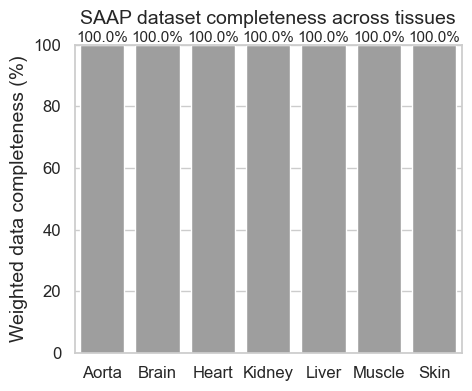

In [13]:
# weighted SAAP data completeness per tissue
# if using SAAP_quant_df with 100% data completeness, should read 100% completeness for all tissues
# if using SAAP_quant_df with all observations, may read varying completeness across tissues
comp_cols=[
'Positional_probability',
'SAAP_PEP',
'BP_PEP',
'MTP_PrecInt',
'BP_PrecInt',
'Prec_RAAS',
'MTP_ReportInt',
'BP_ReportInt',
'Reporter_RAAS',
'BP_ReportInt_Norm',
'MTP_ReportInt_Norm'
]

comp_df=SAAP_quant_df.copy()
plot_rows=[]
for ds in sorted(comp_df['Dataset'].dropna().unique()):
    ds_df=comp_df[comp_df['Dataset']==ds]
    total_values=len(ds_df)*len(comp_cols)
    nonmissing_values=sum(
        ds_df[c].notna().sum()
        for c in comp_cols
    )
    completeness=100*(nonmissing_values/total_values)
    plot_rows.append([ds,completeness])

plot_df=pd.DataFrame(plot_rows,columns=['Dataset','Completeness'])
fig,ax=plt.subplots(figsize=(5,4))
sns.barplot(data=plot_df,x='Dataset',y='Completeness',color='#9E9E9E')
ax.tick_params('both',labelsize=12)
plt.xlabel('')
plt.ylabel('Weighted data completeness (%)',fontsize=14)
plt.ylim(0,100)
plt.title('SAAP dataset completeness across tissues',fontsize=14,pad=15)
plt.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=11)

plt.savefig(PLOT_DIR+'SAAP_weighted_data_completeness_by_tissue.pdf', bbox_inches='tight')

Aorta
Brain
Heart
Kidney
Liver
Muscle
Skin
Aorta
Brain
Heart
Kidney
Liver
Muscle
Skin


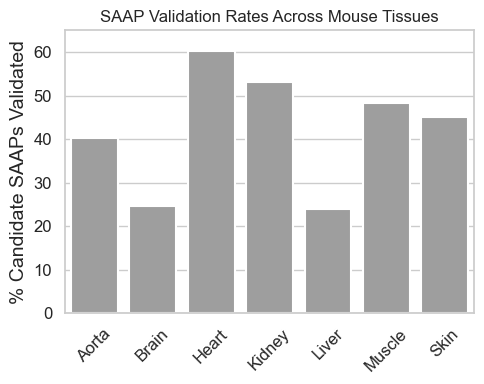

In [14]:
# get dataframe with number of unique substituted peptides, candidate and validated
rows = []
cols = ['Dataset', 'N SAAP sequences', 'SAAP sequence type', 'TMT set']

for i,ds in enumerate(datasets):
    print(ds)
    samples = samples_list[i]
    data_dir = data_dir_list[i]
    for s in samples:
        n_seqs = get_n_unq_seqs(data_dir, s)
        n_val_seqs = get_n_unq_val(data_dir, s)
        rows.append([ds, n_seqs, 'Candidate', s])
        rows.append([ds, n_val_seqs, 'Validated', s])
plt_df = pd.DataFrame(rows, columns=cols)

# get dataframe with percentage of peptides validated and percentage of peptides with no genome homology (from ds_filter_dict.p generated above)
pcnt_rows = []
for i,ds in enumerate(datasets):
    print(ds)
    data_dir = data_dir_list[i]
    samples = samples_list[i]
    ds_plt_df = plt_df.loc[plt_df['Dataset']==ds,:]
    ds_filter_dict = filter_dict[ds]
    for j,s in enumerate(samples):
        s_df = ds_plt_df.loc[ds_plt_df['TMT set']==s,:]
        n_cand = s_df.loc[s_df['SAAP sequence type']=='Candidate', 'N SAAP sequences'].values[0]
        n_val = s_df.loc[s_df['SAAP sequence type']=='Validated', 'N SAAP sequences'].values[0]
        val_pcnt = 100*(n_val/n_cand)
        n_aas = ds_filter_dict['AAS'][j]
        pcnt_rows.append([ds,s, val_pcnt, 'Validated SAAP'])
pcnt_df = pd.DataFrame(pcnt_rows, columns=['Dataset', 'TMT set', '% peptides', '% type'])
nonrectum_row = [i for i,row in pcnt_df.iterrows() if (row['TMT set']!='rectum') and (row['TMT set']!='bonemarrow')] # too little data, removed these tissues from analysis
pcnt_df = pcnt_df.loc[nonrectum_row]
pcnt_df.to_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx')
# pcnt_df = pd.read_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx', index_col=0)

# plot percentage of candidate SAAPs validated across samples
sns.set(style="whitegrid")  
fig, ax = plt.subplots(figsize=(5, 4))  
c_palette = {'Validated SAAP': '#9E9E9E'}
avg_pcnt_df = pcnt_df.groupby(['Dataset', 'TMT set', '% type'], as_index=False).agg({'% peptides': 'mean'})
sns.barplot(data=avg_pcnt_df, x='Dataset', y='% peptides', hue='% type', ax=ax, dodge=True,
            palette = c_palette, edgecolor='white', linewidth=1.5)
ax.get_legend().remove()
plt.ylim(0, 65) 
plt.yticks(fontsize=12)  
plt.xticks(rotation=45, fontsize=12)  
plt.xlabel('', fontsize=14)  
plt.title('SAAP Validation Rates Across Mouse Tissues')
plt.ylabel('% Candidate SAAPs Validated', fontsize=14)  
plt.tight_layout()

plt.savefig(PLOT_DIR + 'percent_validated_allDS_boxplot.pdf', bbox_inches='tight')
plt.show()

## Post-Translational Modifications

Aorta
Brain


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)


Heart


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)


Kidney
Liver


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_object

Muscle
Skin
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
Extracting top PTMs by frequency into a plotting dataframe
finding number of peptide IDs
['Dataset', 'Identified PSMs (1% FDR)', 'Peptides', 'Peptides (evidence)', 'Unique peptides']
normalizing PTM plot df by per thousand peptides
finished!


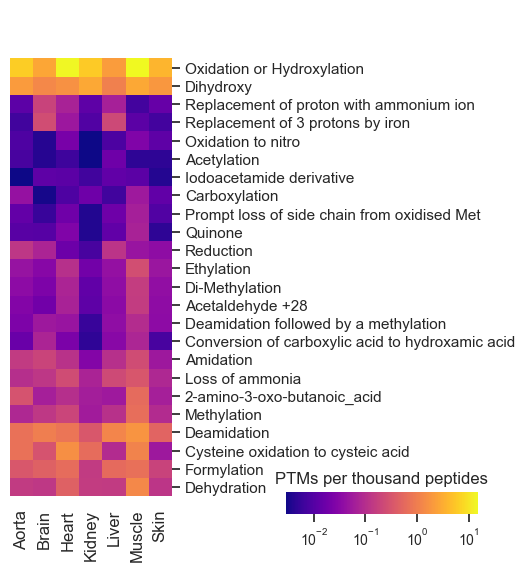

In [15]:
# get PTM dataframe for each dataset
for i in range(len(datasets)):
    print(datasets[i])
    data_dir =  data_dir_list[i]
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    heatmap_df = get_ptm_df(ptm_dict, ds)
    heatmap_df.to_excel(DEPDIR+'PTM_heatmap_df.xlsx')
    
# create a dictionary with the PTM dataframes for each dataset
ptm_heatmap_dict = {}
for i,ds in enumerate(datasets):
    data_dir = data_dir_list[i]
    print("creating dictionary with PTM dataframes for each dataset")
    ptm_df = pd.read_excel(data_dir + 'PTM_heatmap_df.xlsx', index_col=0)
    ptm_df['avg'] = [np.mean(row.values) for i,row in ptm_df.iterrows()]
    ptm_df.sort_values('avg', ascending=False, inplace=True) # sort by frequency to extract top PTMs for plot
    
    ptm_df.index = [x[0].upper()+x[1:] for x in ptm_df.index]
    ptm_heatmap_dict[ds] = ptm_df
    
pickle.dump(ptm_heatmap_dict, open(DEPDIR+'PTM_heatmap_dict.p', 'wb'))
#ptm_heatmap_dict = pickle.load(open(nofilter_outdir+'PTM_heatmap_dict.p', 'rb'))


# extract the top PTMs by frequency into a dataframe for plotting
print("Extracting top PTMs by frequency into a plotting dataframe")
top20 = []
for ds, ds_df in ptm_heatmap_dict.items():
    if len(top20)==0:
        top20 = ds_df.index.values[0:40]
    else:
        top20new = ds_df.index.values[0:40]
        top20 = [x for x in top20 if x in top20new]
plot_df = pd.DataFrame(index=top20, columns=datasets)
for ptm in top20:
    for ds in datasets:
        heatmap_df = ptm_heatmap_dict[ds]
        plot_df.loc[ptm,ds] = heatmap_df.loc[ptm,'avg']
plot_df = plot_df.astype(float)

# need number of peptides IDd to normalize N each PTM per 1000 peptides
print("finding number of peptide IDs")
ds_metrics= pd.read_excel(DEPDIR+'dataset_metrics.xlsx') # dataframe created externally with number of peptides identified in the main seach of each dataset
print(ds_metrics.columns.tolist())  # Print column names exactly as they are

n_peptides_list = []
for ds in datasets:
    n_peptides = ds_metrics.loc[ds_metrics['Dataset']==ds, 'Peptides (evidence)'].values[0]
    n_peptides_list.append(n_peptides)

# normalize PTM plot df by per thousand peptides
print("normalizing PTM plot df by per thousand peptides")
scaled_plot_df = deepcopy(plot_df)
for i,ds in enumerate(datasets):
    scaled_plot_df[ds] = [x/(n_peptides_list[i]/1000) for x in scaled_plot_df[ds]]
scaled_plot_df.to_excel(DEPDIR+'PTM_heatmap_data.xlsx')

print("finished!")

# plot ptm heatmap
cg = sns.clustermap(
    data=scaled_plot_df,
    yticklabels=True,
    norm=LogNorm(),
    cbar_kws={
        'orientation': 'horizontal',
        'ticks': [0.01, 0.1, 1, 10]
    },
    figsize=(5.5, 5.5),
    cmap=sns.color_palette('plasma', as_cmap=True),
    method='ward',
    col_cluster=False,
    row_cluster=True,
    dendrogram_ratio=(0.05, 0.1),
    cbar_pos=(0.55, 0.05, 0.35, 0.04)
)

cg.ax_cbar.set_title('PTMs per thousand peptides', fontsize=12, pad=6)
cg.ax_cbar.tick_params(labelsize=10)
cg.ax_cbar.minorticks_off() 

plt.setp(cg.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=12)
plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), fontsize=11)
cg.ax_row_dendrogram.set_visible(False)

plt.savefig(PLOT_DIR + 'PTM_heatmap_top20.pdf', bbox_inches='tight')

## Validation Metrics

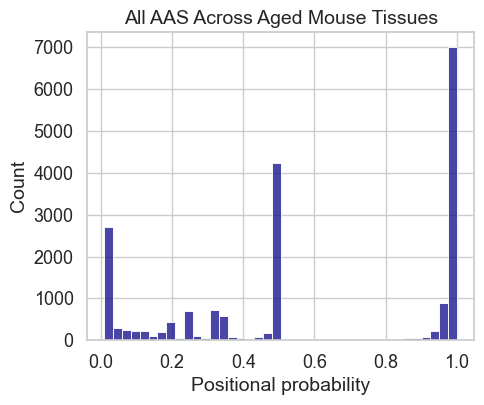

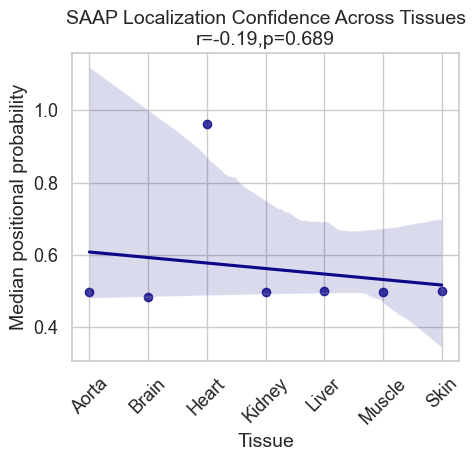

In [16]:
# positional probability distribution
fig,ax=plt.subplots(figsize=(5,4))
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color='#0D0887')
ax.tick_params('both',labelsize=13)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.title('All AAS Across Aged Mouse Tissues',fontsize=14)
plt.savefig(PLOT_DIR+'loc_prob_all_AAS.pdf',bbox_inches='tight')

# positional probability correlation across tissues
loc_df=SAAP_quant_df.copy()
loc_df=loc_df.replace([np.inf,-np.inf],np.nan).dropna(subset=['Positional_probability'])
tissue_corr=loc_df.groupby('Dataset')['Positional_probability'].median().reset_index()
# tissue_corr=loc_df.groupby('Dataset')['Positional_probability'].mean().reset_index()
tissue_corr['Dataset_num']=range(len(tissue_corr))
r,p=sp.stats.pearsonr(tissue_corr['Dataset_num'],tissue_corr['Positional_probability'])

fig,ax=plt.subplots(figsize=(5,4))
sns.regplot(data=tissue_corr,x='Dataset_num',y='Positional_probability',color='#0D0887')
ax.tick_params('both',labelsize=13)
ax.set_xticks(tissue_corr['Dataset_num'])
ax.set_xticklabels(tissue_corr['Dataset'],rotation=45)
plt.xlabel('Tissue',fontsize=14)
plt.ylabel('Median positional probability',fontsize=14)
# plt.ylabel('Mean positional probability',fontsize=14)
plt.title(f'SAAP Localization Confidence Across Tissues\nr={r:.2f},p={p:.3g}',fontsize=14)
plt.savefig(PLOT_DIR+'loc_prob_tissue_correlation.pdf',bbox_inches='tight')

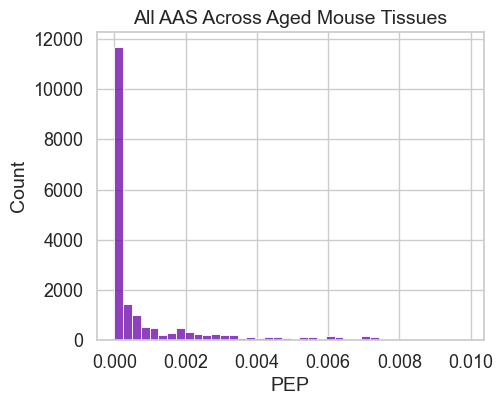

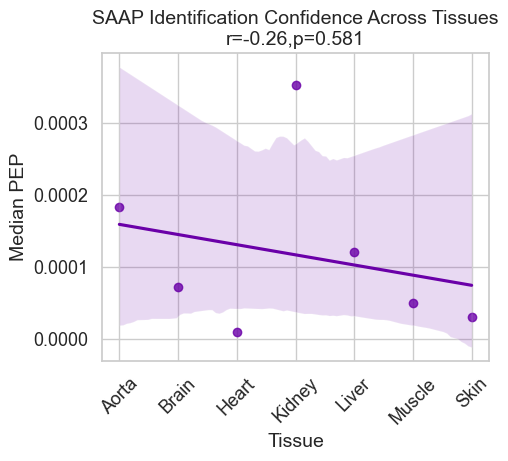

In [17]:
# SAAP PEP distribution
fig,ax=plt.subplots(figsize=(5,4))
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color='#6A00A8')
ax.tick_params('both',labelsize=13)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.title('All AAS Across Aged Mouse Tissues',fontsize=14)
plt.savefig(PLOT_DIR+'SAAP_PEP_distribution.pdf',bbox_inches='tight')

# SAAP PEP correlation across tissues
pep_df=SAAP_quant_df.copy()
pep_df=pep_df.replace([np.inf,-np.inf],np.nan).dropna(subset=['SAAP_PEP'])
tissue_corr=pep_df.groupby('Dataset')['SAAP_PEP'].median().reset_index()
tissue_corr['Dataset_num']=range(len(tissue_corr))
r,p=sp.stats.pearsonr(tissue_corr['Dataset_num'],tissue_corr['SAAP_PEP'])

fig,ax=plt.subplots(figsize=(5,4))
sns.regplot(data=tissue_corr,x='Dataset_num',y='SAAP_PEP',color='#6A00A8')
ax.tick_params('both',labelsize=13)
ax.set_xticks(tissue_corr['Dataset_num'])
ax.set_xticklabels(tissue_corr['Dataset'],rotation=45)
plt.xlabel('Tissue',fontsize=14)
plt.ylabel('Median PEP',fontsize=14)
plt.title(f'SAAP Identification Confidence Across Tissues\nr={r:.2f},p={p:.3g}',fontsize=14)
plt.savefig(PLOT_DIR+'SAAP_PEP_tissue_correlation.pdf',bbox_inches='tight')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


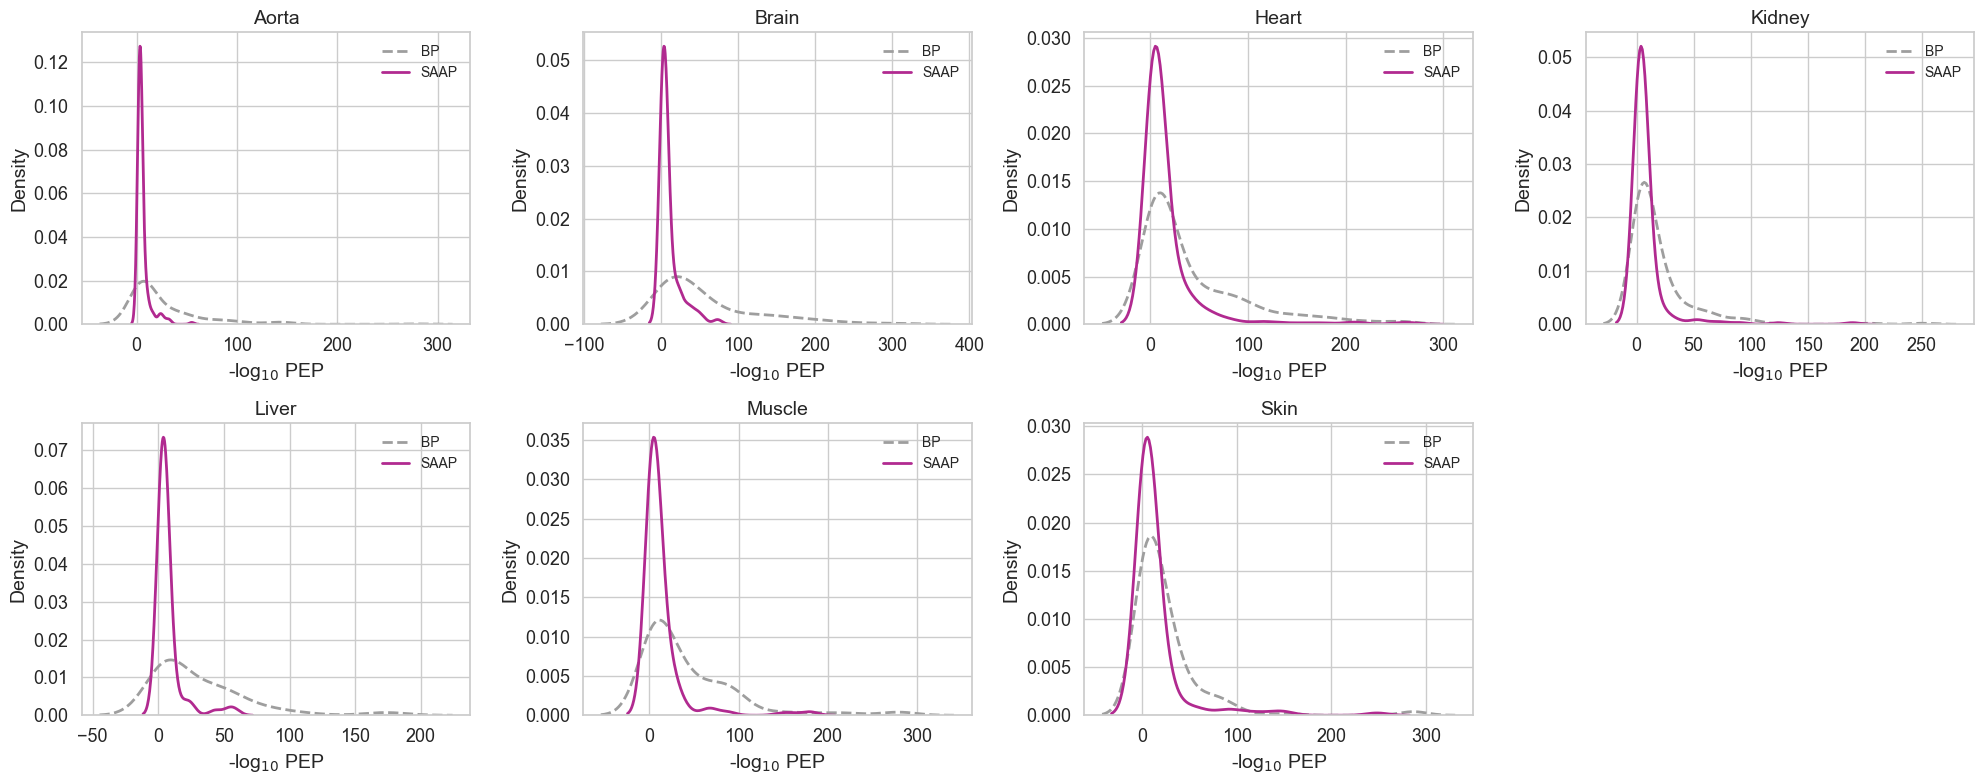

In [18]:
# SAAP vs BP PEP distribution by tissue
datasets=sorted(SAAP_quant_df['Dataset'].dropna().unique())
ncols=4
nrows=int(np.ceil(len(datasets)/ncols))
fig,axes=plt.subplots(figsize=(5*ncols,4*nrows),nrows=nrows,ncols=ncols)
axes=np.array(axes).flatten()
for ax,ds in zip(axes,datasets):
    df=SAAP_quant_df[SAAP_quant_df['Dataset']==ds].drop_duplicates(subset=['MTP_seq','tmt_set'])
    saap_pep=-np.log10(df['SAAP_PEP']).replace([np.inf,-np.inf],np.nan).dropna()
    bp_pep=-np.log10(df['BP_PEP']).replace([np.inf,-np.inf],np.nan).dropna()
    sns.kdeplot(x=bp_pep,label='BP',linewidth=2,linestyle='--',color='#9E9E9E',ax=ax)
    sns.kdeplot(x=saap_pep,label='SAAP',linewidth=2,color='#B12A90',ax=ax)
    ax.tick_params('both',labelsize=13)
    plt.sca(ax)
    plt.xlabel('-log$_{10}$ PEP',fontsize=14)
    plt.ylabel('Density',fontsize=14)
    plt.title(ds,fontsize=14)
    plt.legend(fontsize=10,frameon=False)
for ax in axes[len(datasets):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(PLOT_DIR+'SAAP_BP_PEP_kde_by_tissue.pdf',bbox_inches='tight')

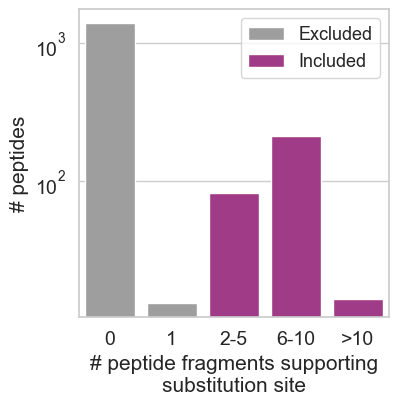

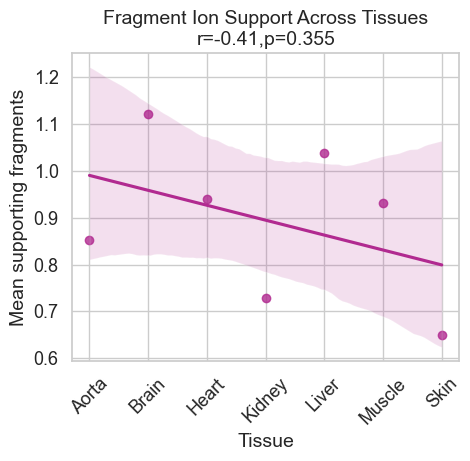

In [19]:
# number of fragment ions supporting substitution site
# plot n fragments barplots
plot_df = pd.read_excel(DEPDIR+'by_fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=plot_df, x='Bin', y='Count', hue='Used', dodge=False, palette=['#9E9E9E', '#B12A90'])
ax.tick_params('both', labelsize=14)

plt.ylabel('# peptides', fontsize=15)
handles, labels = ax.get_legend_handles_labels()
plt.yscale("log")
plt.legend(handles=handles, loc='upper right', labels=['Excluded', 'Included'], fontsize=13)
plt.xlabel('# peptide fragments supporting\nsubstitution site', fontsize=15)
plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.pdf', bbox_inches='tight')

# fragment ion support correlation across tissues
frag_df=pos_prob_df.copy()
frag_df['N_fragments']=frag_df[['bp_b_left_frag_mass','bp_b_right_frag_mass','bp_y_left_frag_mass','bp_y_right_frag_mass']].notna().sum(axis=1)
frag_df=frag_df.drop_duplicates(subset=['SAAP','TMT set'])
tissue_corr=frag_df.groupby('Dataset')['N_fragments'].mean().reset_index()
# tissue_corr=frag_df.groupby('Dataset')['N_fragments'].median().reset_index()
tissue_corr['Dataset_num']=range(len(tissue_corr))
r,p=sp.stats.pearsonr(tissue_corr['Dataset_num'],tissue_corr['N_fragments'])
fig,ax=plt.subplots(figsize=(5,4))
sns.regplot(data=tissue_corr,x='Dataset_num',y='N_fragments',color='#B12A90')
ax.tick_params('both',labelsize=13)
ax.set_xticks(tissue_corr['Dataset_num'])
ax.set_xticklabels(tissue_corr['Dataset'],rotation=45)
plt.xlabel('Tissue',fontsize=14)
plt.ylabel('Mean supporting fragments',fontsize=14)
# plt.ylabel('Median supporting fragments',fontsize=14)
plt.title(f'Fragment Ion Support Across Tissues\nr={r:.2f},p={p:.3g}',fontsize=14)
plt.savefig(PLOT_DIR+'fragment_ion_evidence_tissue_correlation.pdf',bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3955045548.py:15: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3955045548.py:16: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)


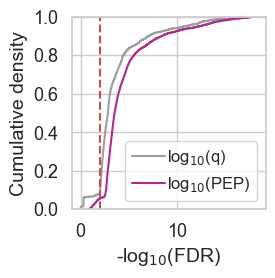

In [20]:
# cumulative density of q-values and PEPs across all datasets and samples
# plot the p-values determined by MaxQuant and the q-values determined from only the substituted peptides
plot_rows = []
plot_cols = ['Dataset', 'TMT/Tissue', 'q-value', 'PEP']
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    qmtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    for s in samples:
        s_dict = qmtp_dict[s]
        for k,v in s_dict['Posterior subs probability'].items():
            plot_rows.append([ds, s, 1-v[0], s_dict['q-value'][k][0]])
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)

plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
fig,ax = plt.subplots(figsize=(2.5,2.5))
sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', color='#9E9E9E')
sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', color='#B12A90')
plt.ylabel('Cumulative density', fontsize=14)
plt.xlabel('-log$_{10}$(FDR)', fontsize=14)
ax.tick_params('both', labelsize=13)
plt.plot((2,2), plt.ylim(), '--r')
plt.legend(loc='lower right', fontsize=12, handletextpad=0.1)
plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.pdf', bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:53: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:53: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/1502314769.py:35: SyntaxWarning: invalid escape sequence '\g'
  all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/1502314769.py:43: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, color='#9E9E9E', label='log$_{10}$(RAAS)$\geq$0')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/1502314769.py:53: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_ra

Aorta
Brain
Heart
Kidney
Liver
Muscle
Skin


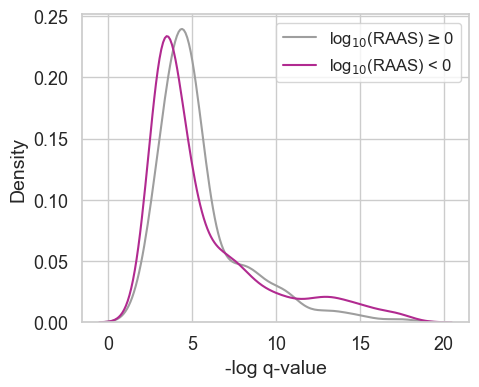

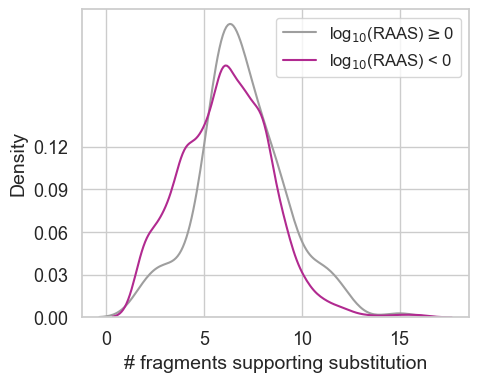

In [21]:
# cumulative density of q-values and PEPs across all datasets and samples stratified by RAAS
# generate a dictionary with PEP values and N fragments for all SAAP in all datasets 
paas_pep_dict = {}
for ds in datasets:
    print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    mtp_dict = pickle.load(open(data_dir + 'Ion_validated_MTP_dict.p', 'rb'))
    mtp_quant_dict = pickle.load(open(data_dir + 'MTP_quant_dict.p', 'rb'))

    plot_rows = []
    plot_cols = ['Dataset', 'Sample', 'PAAS', 'PAAS_val_idx', 'DP PEP', 'PAAS PEP', 'PAAS q', 'PAAS Precursor Intensity','BP Precursor Intensity', 'Precursor RAAS', 'N fragments']
    for s in samples:
        s_dict = mtp_dict[s]
        for k, paas in s_dict['mistranslated sequence'].items():
            paas_pep = s_dict['Posterior subs probability'][k]
            paas_q = s_dict['q-value'][k]
            dp_pep = s_dict['DP PEP'][k]
            n_frags = s_dict['fragment_evidence'][k]
            q_dict = [i for i,v in mtp_quant_dict.items() if v['MTP_seq']==paas]
            if len(q_dict)>0:
                q_dict = mtp_quant_dict[q_dict[0]]
                paas_prec = q_dict['MTP_PrecInt'][s]
                bp_prec = q_dict['BP_PrecInt'][s]
                raas = q_dict['Prec_ratio'][s]
                if (~np.isnan(raas)) and (~np.isinf(raas)):
                    plot_rows.append([ds, s, paas, k, dp_pep, paas_pep, paas_q, paas_prec, bp_prec, raas, n_frags])
    plot_df = pd.DataFrame(plot_rows, columns=plot_cols)   
    paas_pep_dict[ds] = plot_df

pickle.dump(paas_pep_dict, open(OUTDIR+'SAAP_PEP_dfs.p', 'wb'))

# create data frame for plot 
all_ds_plot_df = pd.concat([v for k,v in paas_pep_dict.items()])
all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
all_ds_plot_df = all_ds_plot_df.loc[all_ds_plot_df['PAAS q']<=0.01]

# plot histogram of confidence values stratified by RAAS
fig,ax = plt.subplots(figsize=(5,4))
all_ds_plot_df['-log q'] = [-np.log10(x) for x in all_ds_plot_df['PAAS q']]
high_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']>=0]
low_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']<0]
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, color='#9E9E9E', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='-log q', fill=False, label='log$_{10}$(RAAS) < 0', color='#B12A90')
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('-log q-value', fontsize=14)
plt.legend(fontsize=12)
plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.pdf', bbox_inches='tight')

# plot histogram of N fragments on substitution site stratified by RAAS
fig,ax = plt.subplots(figsize=(5,4))
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='N fragments', fill=False, color='#9E9E9E', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='N fragments', fill=False, label='log$_{10}$(RAAS) < 0', color='#B12A90')
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# fragments supporting substitution', fontsize=14)
plt.yticks([0,0.03,0.06,0.09,0.12])
plt.legend(loc='upper right', fontsize=12)
plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.pdf', bbox_inches='tight')

# 2. Analysis of Substitution Types

## Overview of Substitution Frequencies

In [57]:
raas_col = 'Reporter_RAAS'
age_order = ['t06mo', 't15mo', 't24mo', 't30mo']
replicate_keep = [1, 2, 3, 4] # four mice per age group

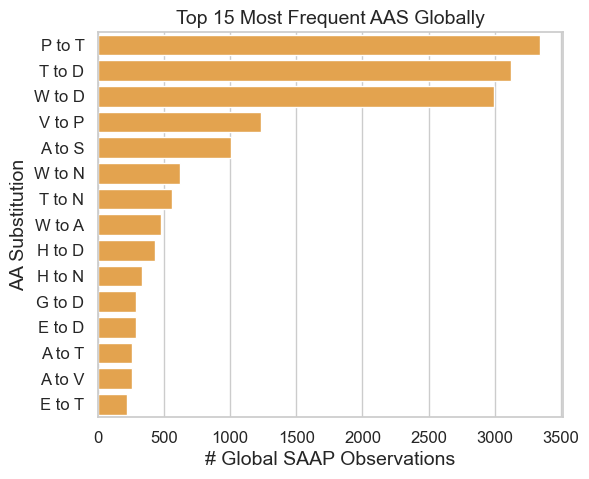

In [58]:
# Count all observed SAAP events and plot the 15 most frequent substitution types
sub_df = SAAP_quant_df.copy()
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)]
sub_order = plot_df['aa_sub'].value_counts().index
fig, ax = plt.subplots(figsize=(6,5))

sns.countplot(data=plot_df, y='aa_sub', order=sub_order, color='#FCA636', ax=ax)
ax.tick_params('both', labelsize=12)
plt.xlabel('# Global SAAP Observations', fontsize=14)
plt.ylabel('AA Substitution', fontsize=14)
plt.title('Top 15 Most Frequent AAS Globally', fontsize=14)
plt.savefig(PLOT_DIR + 'top15_SAAP_substitutions.pdf', bbox_inches='tight')

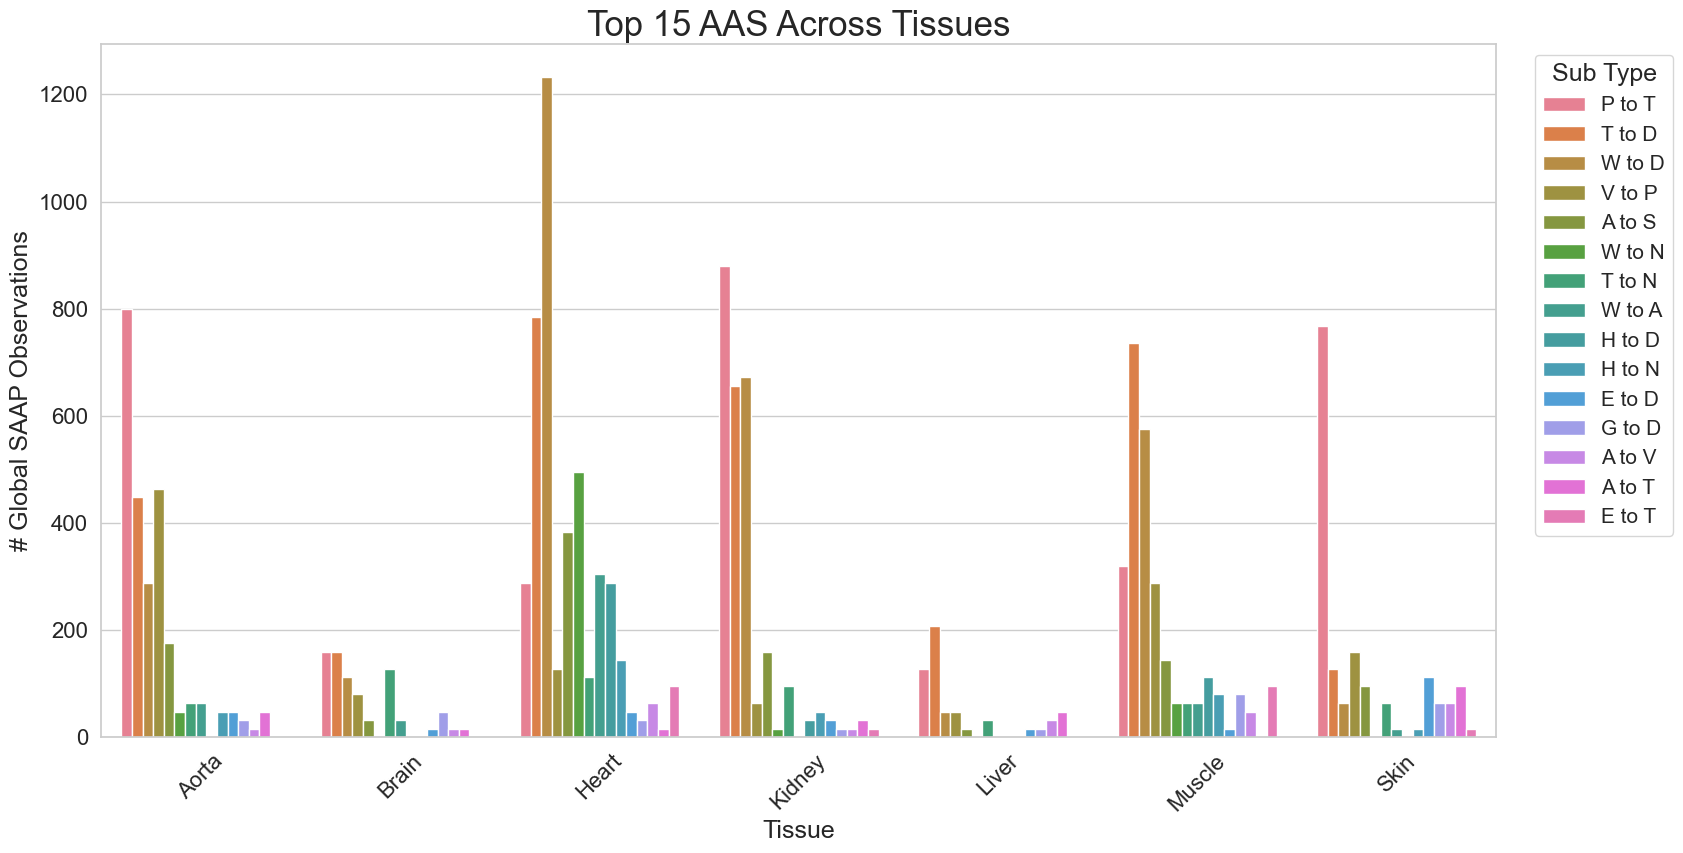

In [59]:
# Plot top substitution types across tissues 
sub_df = SAAP_quant_df.copy()
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = plot_df['aa_sub'].value_counts().loc[top_subs].index
tissue_order = sorted(plot_df['Dataset'].unique())

# Count tissue/sub combinations, retaining 0-count pairs 
global_idx = pd.MultiIndex.from_product([tissue_order,sub_order],names=['Dataset','aa_sub'])
count_df = (plot_df.groupby(['Dataset', 'aa_sub']).size().reindex(global_idx, fill_value=0).reset_index(name='Count'))

fig,ax = plt.subplots(figsize=(18,9))
sns.barplot(data=count_df,x='Dataset',y='Count',hue='aa_sub',hue_order=sub_order,palette=sns.color_palette('husl',len(sub_order)),order=tissue_order,ax=ax)
ax.tick_params(axis='x',rotation=45,labelsize=16)
ax.tick_params(axis='y',labelsize=16)
ax.set_xlabel('Tissue',fontsize=18)
ax.set_ylabel('# Global SAAP Observations',fontsize=18)
ax.set_title('Top 15 AAS Across Tissues',fontsize=25)
ax.legend(title='Sub Type',bbox_to_anchor=(1.02,1),loc='upper left',frameon=True,fontsize=15,title_fontsize=18)
plt.savefig(PLOT_DIR + 'top15_substitutions_across_tissues.pdf',bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/2441931621.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix=(count_df.pivot_table(index='From_AA',columns='To_AA',values='Count',fill_value=0).reindex(index=aa_order,columns=aa_order,fill_value=0))


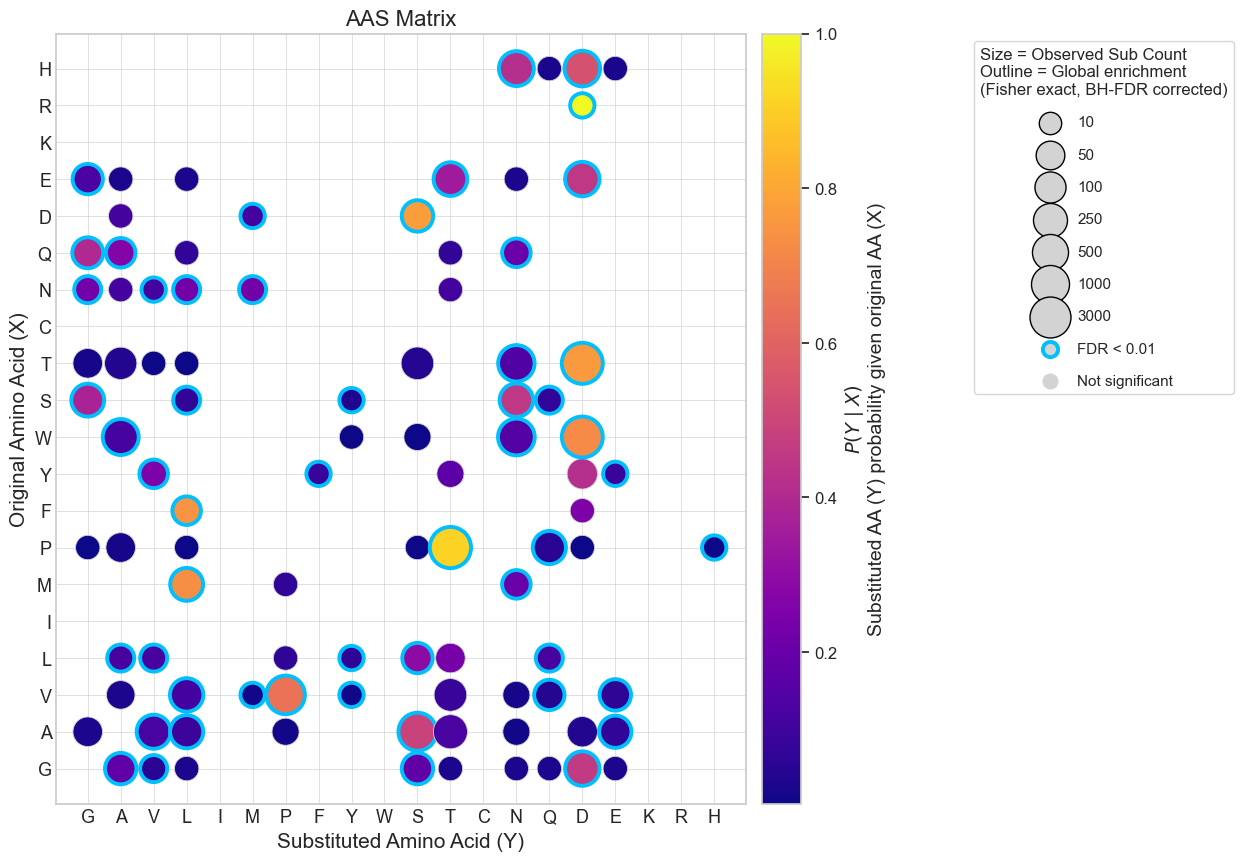

In [64]:
# Global bubble matrix of substitution probabilities and enrichments 
sub_df=SAAP_quant_df.copy()
sub_split=sub_df['aa_sub'].str.split(' to ',expand=True)
sub_df['From_AA']=sub_split[0]
sub_df['To_AA']=sub_split[1]
count_df=(sub_df.groupby(['From_AA','To_AA']).size().reset_index(name='Count'))
count_df=count_df[count_df['From_AA']!=count_df['To_AA']]
count_df['Row_fraction']=count_df.groupby('From_AA')['Count'].transform(lambda x:x/x.sum())
count_df['From_AA']=pd.Categorical(count_df['From_AA'],categories=aa_order,ordered=True)
count_df['To_AA']=pd.Categorical(count_df['To_AA'],categories=aa_order,ordered=True)
count_df=count_df.sort_values(['From_AA','To_AA'])

matrix=(count_df.pivot_table(index='From_AA',columns='To_AA',values='Count',fill_value=0).reindex(index=aa_order,columns=aa_order,fill_value=0))
for aa in aa_order: matrix.loc[aa,aa]=0

obs=matrix.values.astype(float)
row_total=obs.sum(axis=1,keepdims=True)
col_total=obs.sum(axis=0,keepdims=True)
grand_total=obs.sum()
expected=(row_total@col_total)/grand_total

results=[]

for i,from_aa in enumerate(aa_order):
    for j,to_aa in enumerate(aa_order):
        if from_aa==to_aa: continue
        observed=obs[i,j]
        expected_count=expected[i,j]
        row_fraction=(observed/row_total[i,0] if row_total[i,0]>0 else np.nan)
        a=observed
        b=row_total[i,0]-a
        c=col_total[0,j]-a
        d=grand_total-a-b-c
        if min(a,b,c,d)>=0:
            odds_ratio,pval=fisher_exact([[a,b],[c,d]],alternative='greater')
        else:
            odds_ratio,pval=np.nan,np.nan
        results.append([from_aa,to_aa,observed,expected_count,row_fraction,a,b,c,d,odds_ratio,pval])

stats_df=pd.DataFrame(results,columns=['From_AA','To_AA','Observed_count','Expected_count','P_Y_given_X','Observed_thisSwap','Observed_otherFromAA','Observed_otherToAA','Observed_allOther','Odds_ratio','pval'])

stats_df=run_fdr(stats_df,p_col='pval')
stats_df['Sig']=stats_df['FDR']<0.01

# Plotting
plot_df=count_df.merge(stats_df,on=['From_AA','To_AA'],how='left')
plot_df['From_AA']=pd.Categorical(plot_df['From_AA'],categories=aa_order,ordered=True)
plot_df['To_AA']=pd.Categorical(plot_df['To_AA'],categories=aa_order,ordered=True)

fig,ax=plt.subplots(figsize=(13.5,10))

scatter=ax.scatter(x=plot_df['To_AA'].cat.codes,y=plot_df['From_AA'].cat.codes,s=np.log10(plot_df['Observed_count']+1)*250,c=plot_df['P_Y_given_X'],cmap='plasma',edgecolors=np.where(plot_df['Sig'],'deepskyblue','lightgray'),linewidths=np.where(plot_df['Sig'],2.8,0.6))

ax.set_xticks(range(len(aa_order)))
ax.set_yticks(range(len(aa_order)))
ax.set_xticklabels(aa_order,fontsize=13)
ax.set_yticklabels(aa_order,fontsize=13)

ax.grid(color='lightgray',linewidth=0.5)
ax.tick_params('both',length=0)

plt.xlabel('Substituted Amino Acid (Y)',fontsize=15)
plt.ylabel('Original Amino Acid (X)',fontsize=15)
plt.title('AAS Matrix',fontsize=16)

fig.subplots_adjust(right=0.74)

cbar=plt.colorbar(scatter,pad=0.02)
cbar.set_label(r'$P(Y\mid X)$'+'\n'+'Substituted AA (Y) probability given original AA (X)',fontsize=14)
cbar.ax.tick_params(labelsize=12)

max_count=int(plot_df['Observed_count'].max())

if max_count<=25: size_vals=[1,5,10,25]
elif max_count<=100: size_vals=[10,25,50,100]
elif max_count<=500: size_vals=[50,100,250,500]
elif max_count<=1000: size_vals=[10,50,100,250,500,1000]
else: size_vals=[10,50,100,250,500,1000,int(round(max_count,-3))]

size_vals=[v for v in size_vals if v<=max_count]

size_handles=[plt.scatter([],[],s=np.log10(v+1)*250,facecolors='lightgray',edgecolors='black',linewidths=1) for v in size_vals]
size_labels=[str(v) for v in size_vals]

sig_handle=plt.scatter([],[],s=120,facecolors='lightgray',edgecolors='deepskyblue',linewidths=2.8)
nonsig_handle=plt.scatter([],[],s=120,facecolors='lightgray',edgecolors='lightgray',linewidths=0.6)

legend=ax.legend(handles=size_handles+[sig_handle,nonsig_handle],labels=size_labels+['FDR < 0.01','Not significant'],title='Size = Observed Sub Count\nOutline = Global enrichment\n(Fisher exact, BH-FDR corrected)',scatterpoints=1,frameon=True,fontsize=11,title_fontsize=12,loc='upper left',bbox_to_anchor=(1.32,1),labelspacing=1.2)

plt.savefig(PLOT_DIR+'SAAP_substitution_bubble_matrix.pdf',bbox_inches='tight')

stats_df=stats_df.sort_values(['FDR','Observed_count'],ascending=[True,False])

stats_df.to_csv(OUTDIR+'SAAP_substitution_statistics.tsv',sep='\t',index=False)

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/1631572632.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df = (plot_df.groupby(['aa_sub','Tissue'])[raas_col].median().reset_index())


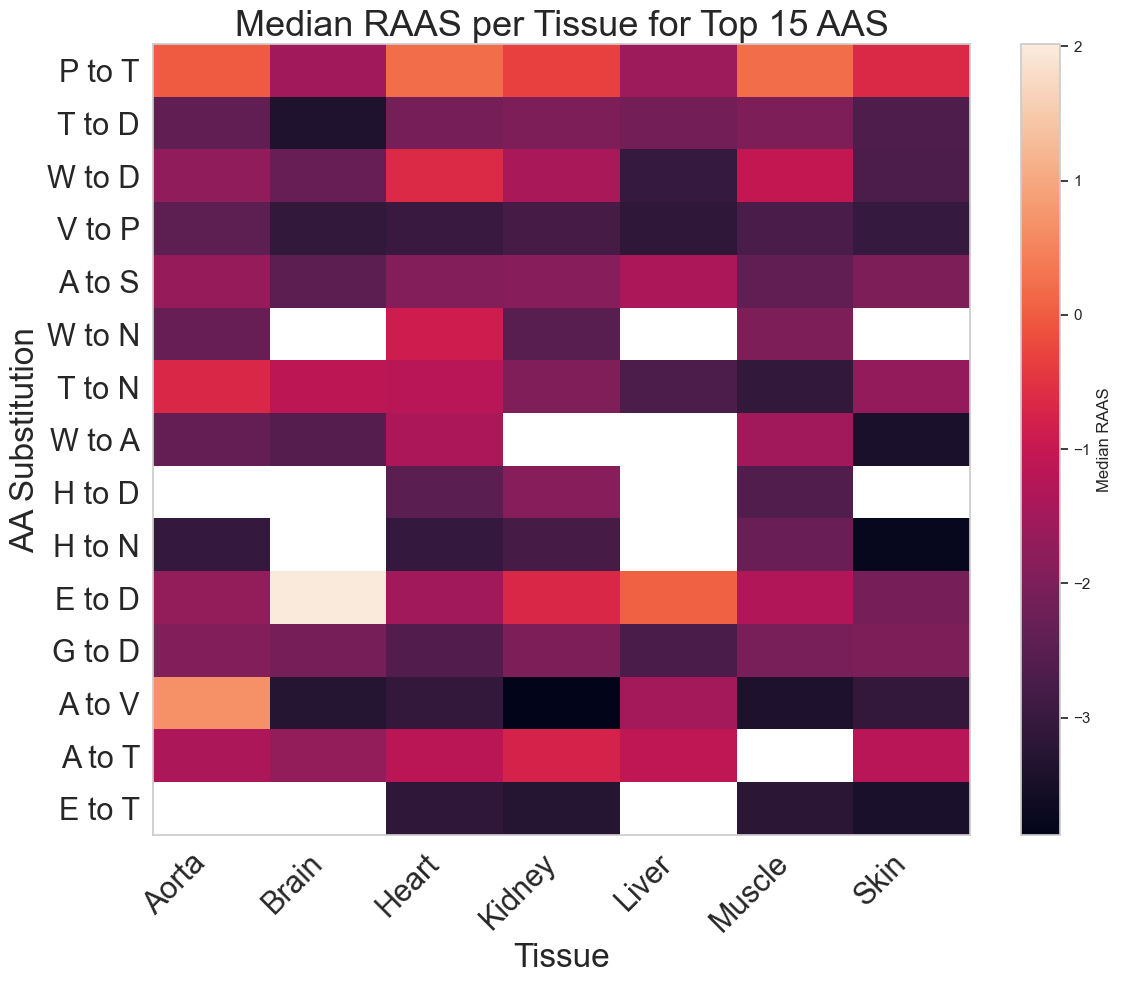

In [61]:
# Compare mean RAAS across tissues per substitution at the global level (no age differentiation)
sub_df = replicate_cols(SAAP_quant_df)
sub_df = sub_df[sub_df['Replicate'].isin(replicate_keep)].copy()

# Select globally most common substitutions
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = plot_df['aa_sub'].value_counts().loc[top_subs].index
tissue_order = sorted(plot_df['Tissue'].dropna().unique())

plot_df['Tissue'] = pd.Categorical(plot_df['Tissue'], categories=tissue_order, ordered=True)
plot_df['aa_sub'] = pd.Categorical(plot_df['aa_sub'], categories=sub_order, ordered=True)

# aggregate RAAS via median 
heatmap_df = (plot_df.groupby(['aa_sub','Tissue'])[raas_col].median().reset_index())
heatmap_matrix = (heatmap_df.pivot(index='aa_sub',columns='Tissue',values=raas_col).reindex(index=sub_order).reindex(columns=tissue_order))

# Plot heatmap of median RAAS per substitution/tissue combination, with global significance outlines.
plt.figure(figsize=(12,10))
plt.imshow(heatmap_matrix,aspect='auto')
plt.colorbar(label='Median RAAS')
plt.xticks(np.arange(len(tissue_order)), tissue_order, rotation=45, ha='right', fontsize=22)
plt.yticks(np.arange(len(heatmap_matrix.index)), heatmap_matrix.index, fontsize=22)
plt.xlabel('Tissue', fontsize=24)
plt.ylabel('AA Substitution', fontsize=24)
plt.title('Median RAAS per Tissue for Top 15 AAS', fontsize=26)
plt.tight_layout()
plt.grid(False)
plt.savefig(PLOT_DIR + 'top15_substitution_ReporterRAAS_tissue_heatmap.pdf', bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/314448154.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df=(plot_base_df.groupby(['aa_sub','Age','Tissue'])[raas_col].median().reset_index())
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/314448154.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df = (plot_df.groupby(['aa_sub','Age','Tissue'])[raas_col].median().reset_index())


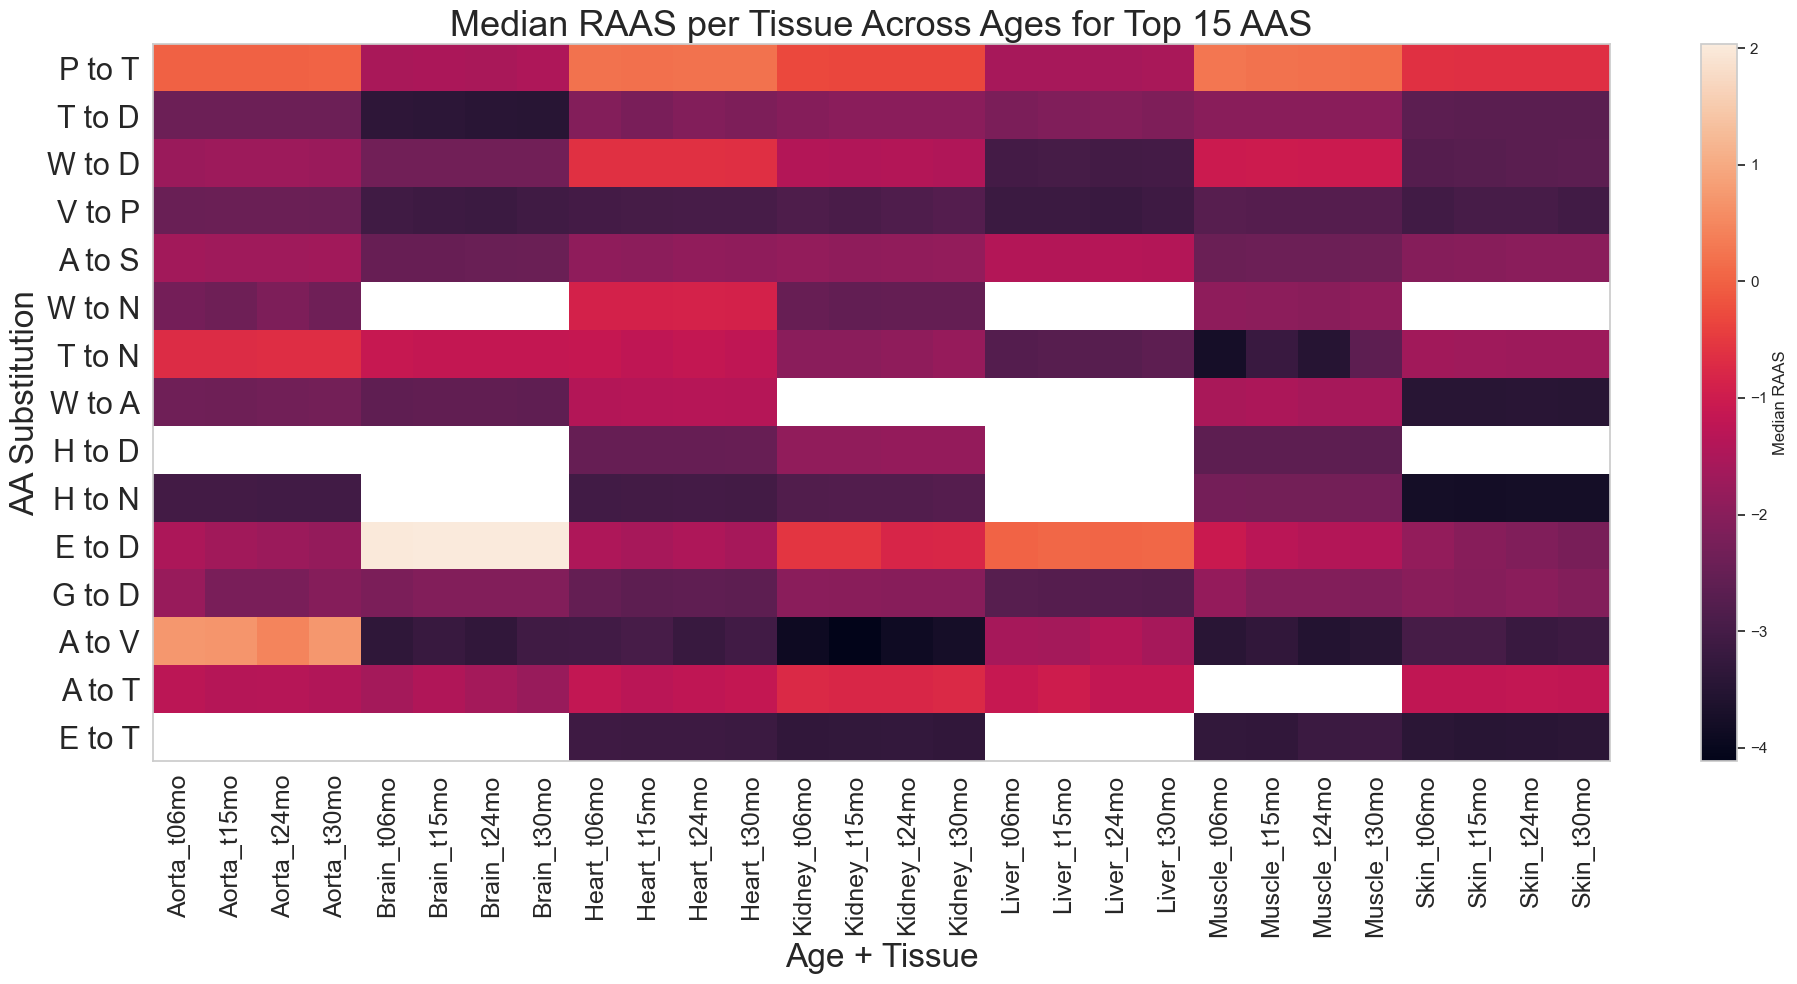

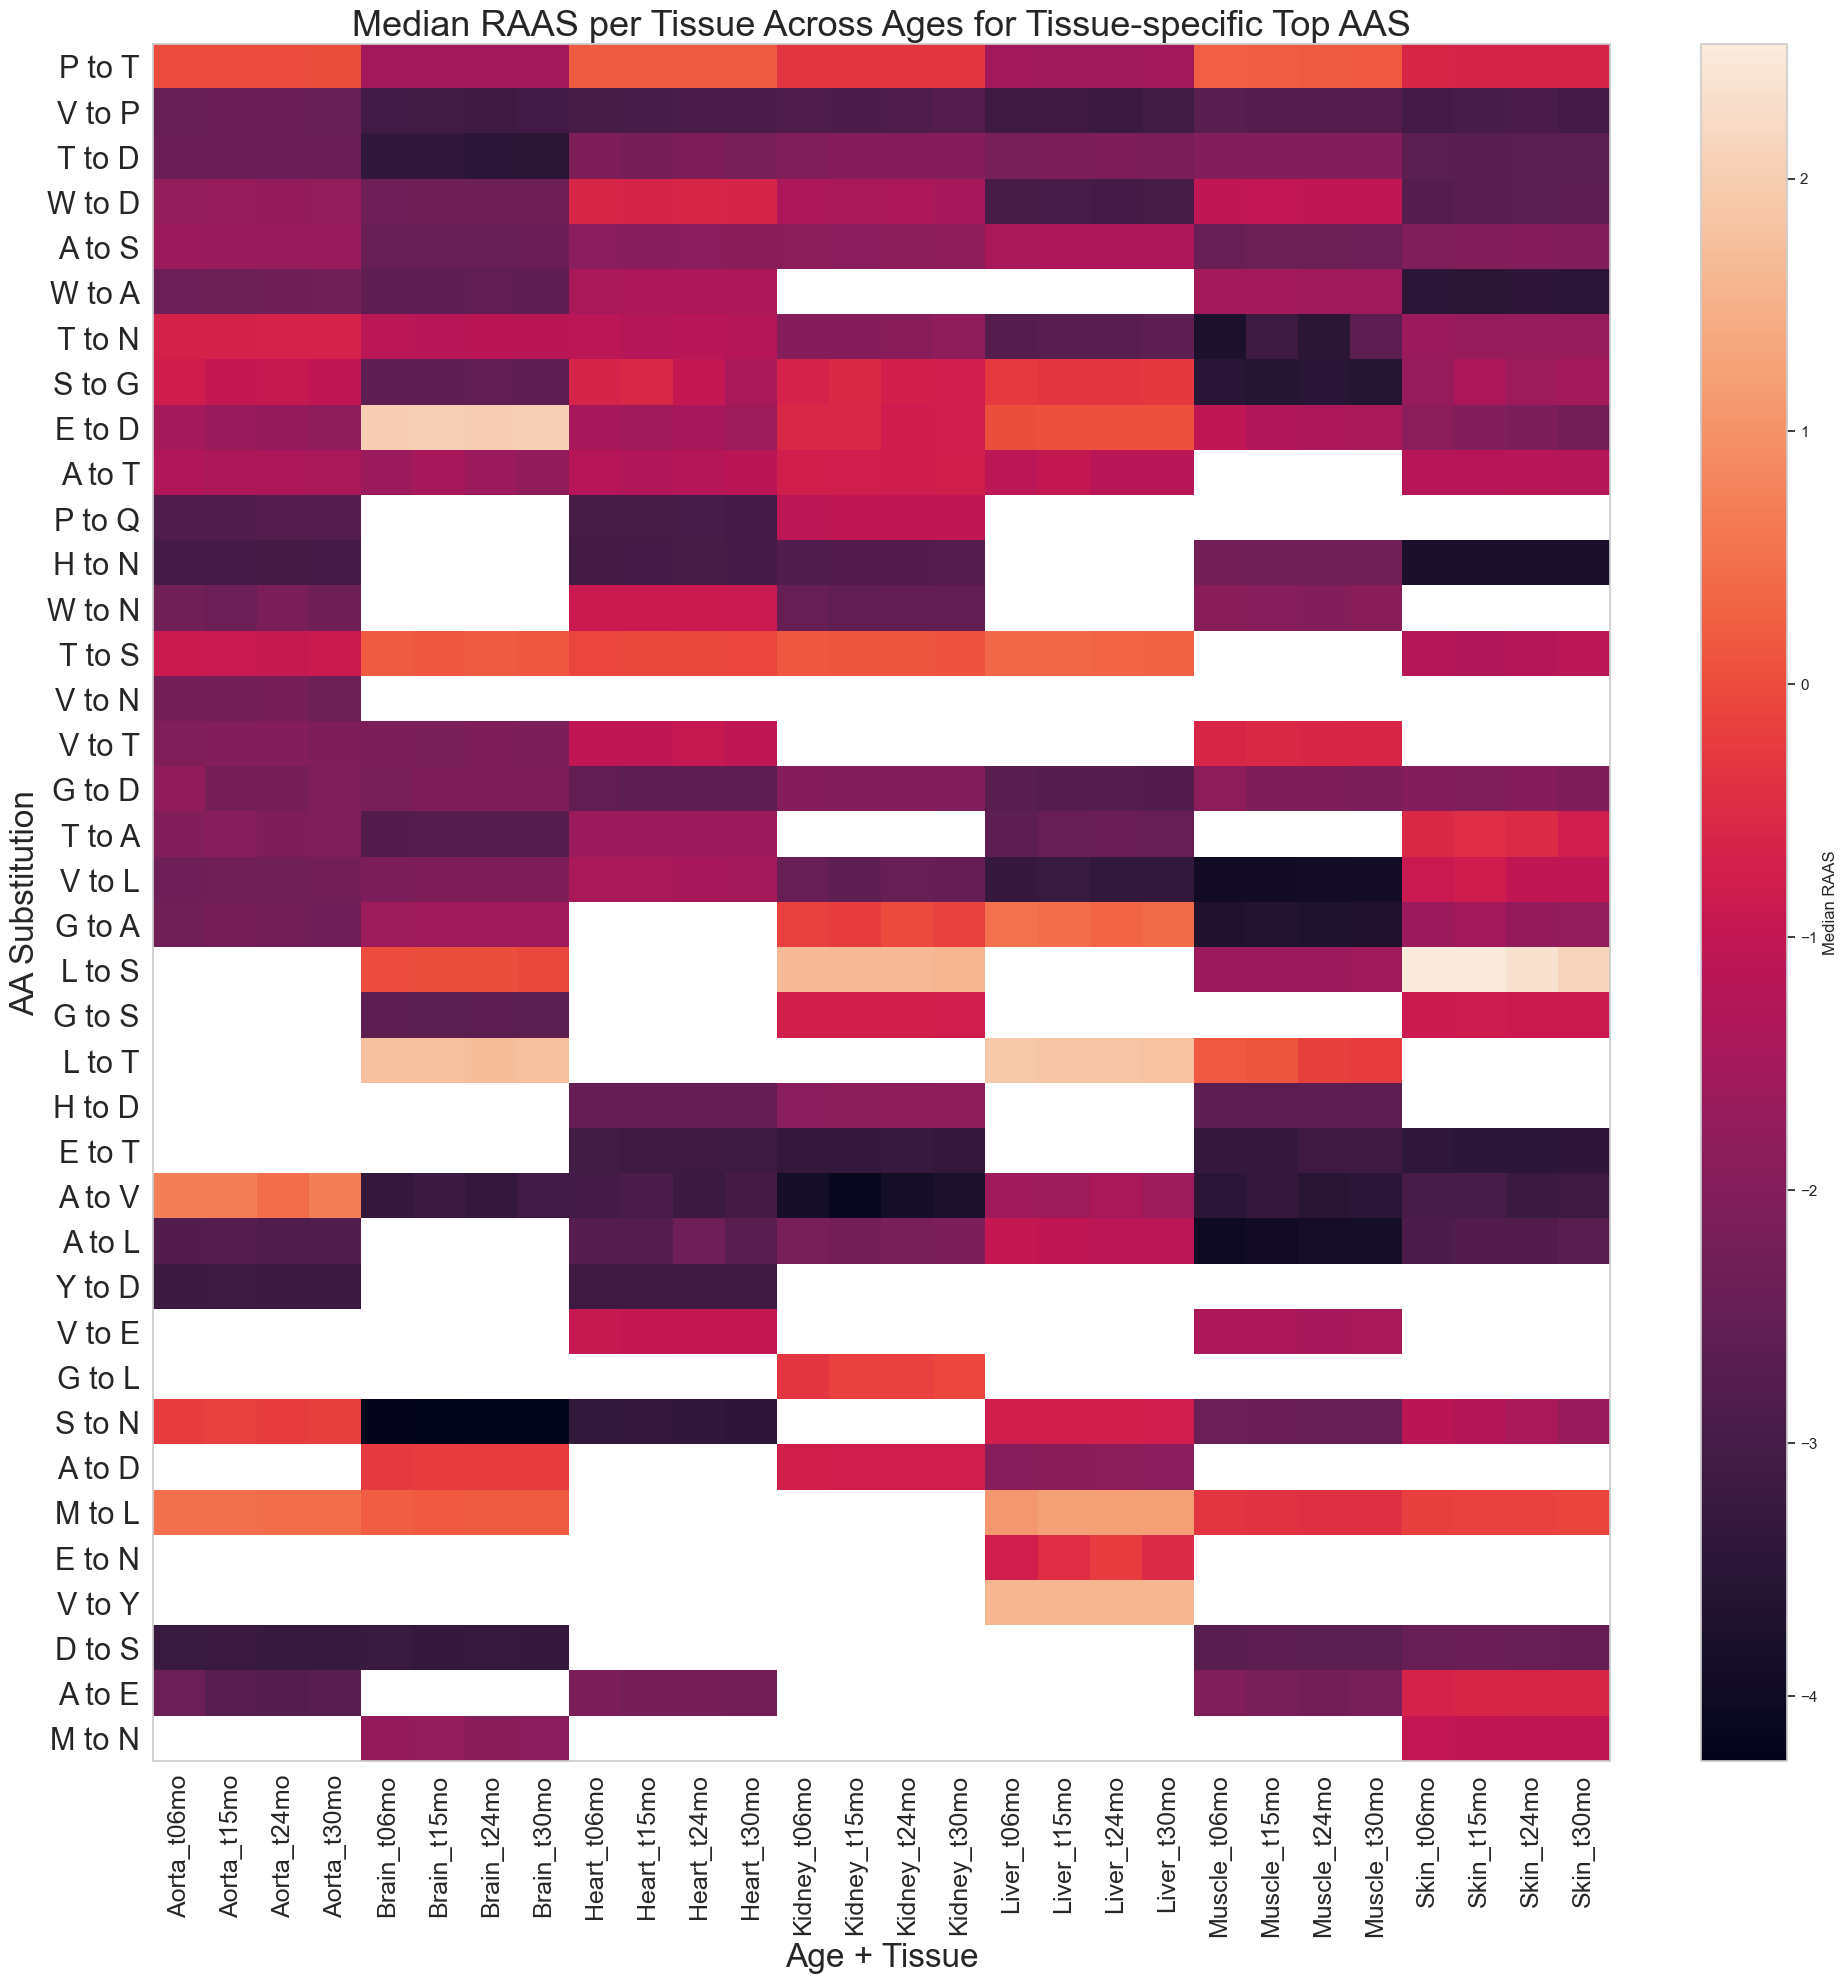

In [62]:
# Repeat the tissue comparison separately within each age group for top subs
sub_df = replicate_cols(SAAP_quant_df)
top_subs = top_sub_order(sub_df, n=15)
plot_base_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = plot_base_df['aa_sub'].value_counts().loc[top_subs].index
tissue_order = sorted(plot_base_df['Tissue'].dropna().unique())

plot_base_df['aa_sub']=pd.Categorical(plot_base_df['aa_sub'],categories=sub_order,ordered=True)
plot_base_df['Tissue']=pd.Categorical(plot_base_df['Tissue'],categories=tissue_order,ordered=True)
plot_base_df['Age']=pd.Categorical(plot_base_df['Age'],categories=age_order,ordered=True)

# aggregate RAAS via median
heatmap_df=(plot_base_df.groupby(['aa_sub','Age','Tissue'])[raas_col].median().reset_index())

heatmap_df['Tissue_Age']=heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Age'].astype(str)

column_order=[]

for tissue in tissue_order:
    for age in age_order:
        column_order.append(tissue+'_'+age)

heatmap_matrix=(heatmap_df.pivot(index='aa_sub',columns='Tissue_Age',values=raas_col).reindex(index=sub_order).reindex(columns=column_order))

# Plot heatmap of median RAAS per substitution/tissue/age combination
plt.figure(figsize=(20,10))
plt.imshow(heatmap_matrix,aspect='auto')
plt.colorbar(label='Median RAAS')
plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=18)
plt.yticks(np.arange(len(heatmap_matrix.index)),heatmap_matrix.index,fontsize=22)
plt.xlabel('Age + Tissue',fontsize=24)
plt.ylabel('AA Substitution',fontsize=24)
plt.title('Median RAAS per Tissue Across Ages for Top 15 AAS',fontsize=26)
plt.tight_layout()
plt.grid(False)

plt.savefig(PLOT_DIR+'top15_substitution_ReporterRAAS_age_tissue_heatmap.pdf',bbox_inches='tight')



# perform the same analysis except for subs most frequent per tissue type 
sub_df = replicate_cols(SAAP_quant_df)
tissue_order = sorted(sub_df['Tissue'].dropna().unique())

top_subs = []
for tissue in tissue_order:
    tissue_top = (sub_df[sub_df['Tissue'] == tissue][['MTP_seq', 'BP_seq', 'aa_sub']].drop_duplicates()['aa_sub'].value_counts().head(15).index.tolist())
    top_subs.extend(tissue_top)
top_subs = list(dict.fromkeys(top_subs))

plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = (plot_df['aa_sub'].value_counts().reindex(top_subs).dropna().index)

plot_df['aa_sub'] = pd.Categorical(plot_df['aa_sub'],categories=sub_order,ordered=True)
plot_df['Tissue'] = pd.Categorical(plot_df['Tissue'],categories=tissue_order,ordered=True)
plot_df['Age'] = pd.Categorical(plot_df['Age'],categories=age_order,ordered=True)

# aggregate RAAS by median
heatmap_df = (plot_df.groupby(['aa_sub','Age','Tissue'])[raas_col].median().reset_index())
heatmap_df['Tissue_Age'] = (heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Age'].astype(str))
column_order = []
for tissue in tissue_order:
    for age in age_order:
        column_order.append(tissue+'_'+age)
heatmap_matrix = (heatmap_df.pivot(index='aa_sub',columns='Tissue_Age',values=raas_col))

# Plotting heatmap of median RAAS per substitution/tissue/age combination
plt.figure(figsize=(20,20))
plt.imshow(heatmap_matrix, aspect='auto')
plt.colorbar(label='Median RAAS')
plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=18)
plt.yticks(np.arange(len(heatmap_matrix.index)),heatmap_matrix.index,fontsize=22)
plt.xlabel('Age + Tissue', fontsize=24)
plt.ylabel('AA Substitution', fontsize=24)
plt.title('Median RAAS per Tissue Across Ages for Tissue-specific Top AAS', fontsize=26)
plt.tight_layout()
plt.grid(False)
plt.savefig(PLOT_DIR + 'top_substitution_ReporterRAAS_age_tissue_heatmap.pdf',bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/3841359740.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df=(norm_df.groupby(['aa_sub','Age','Tissue'])['log2FC_vs_t06mo'].median().reset_index())


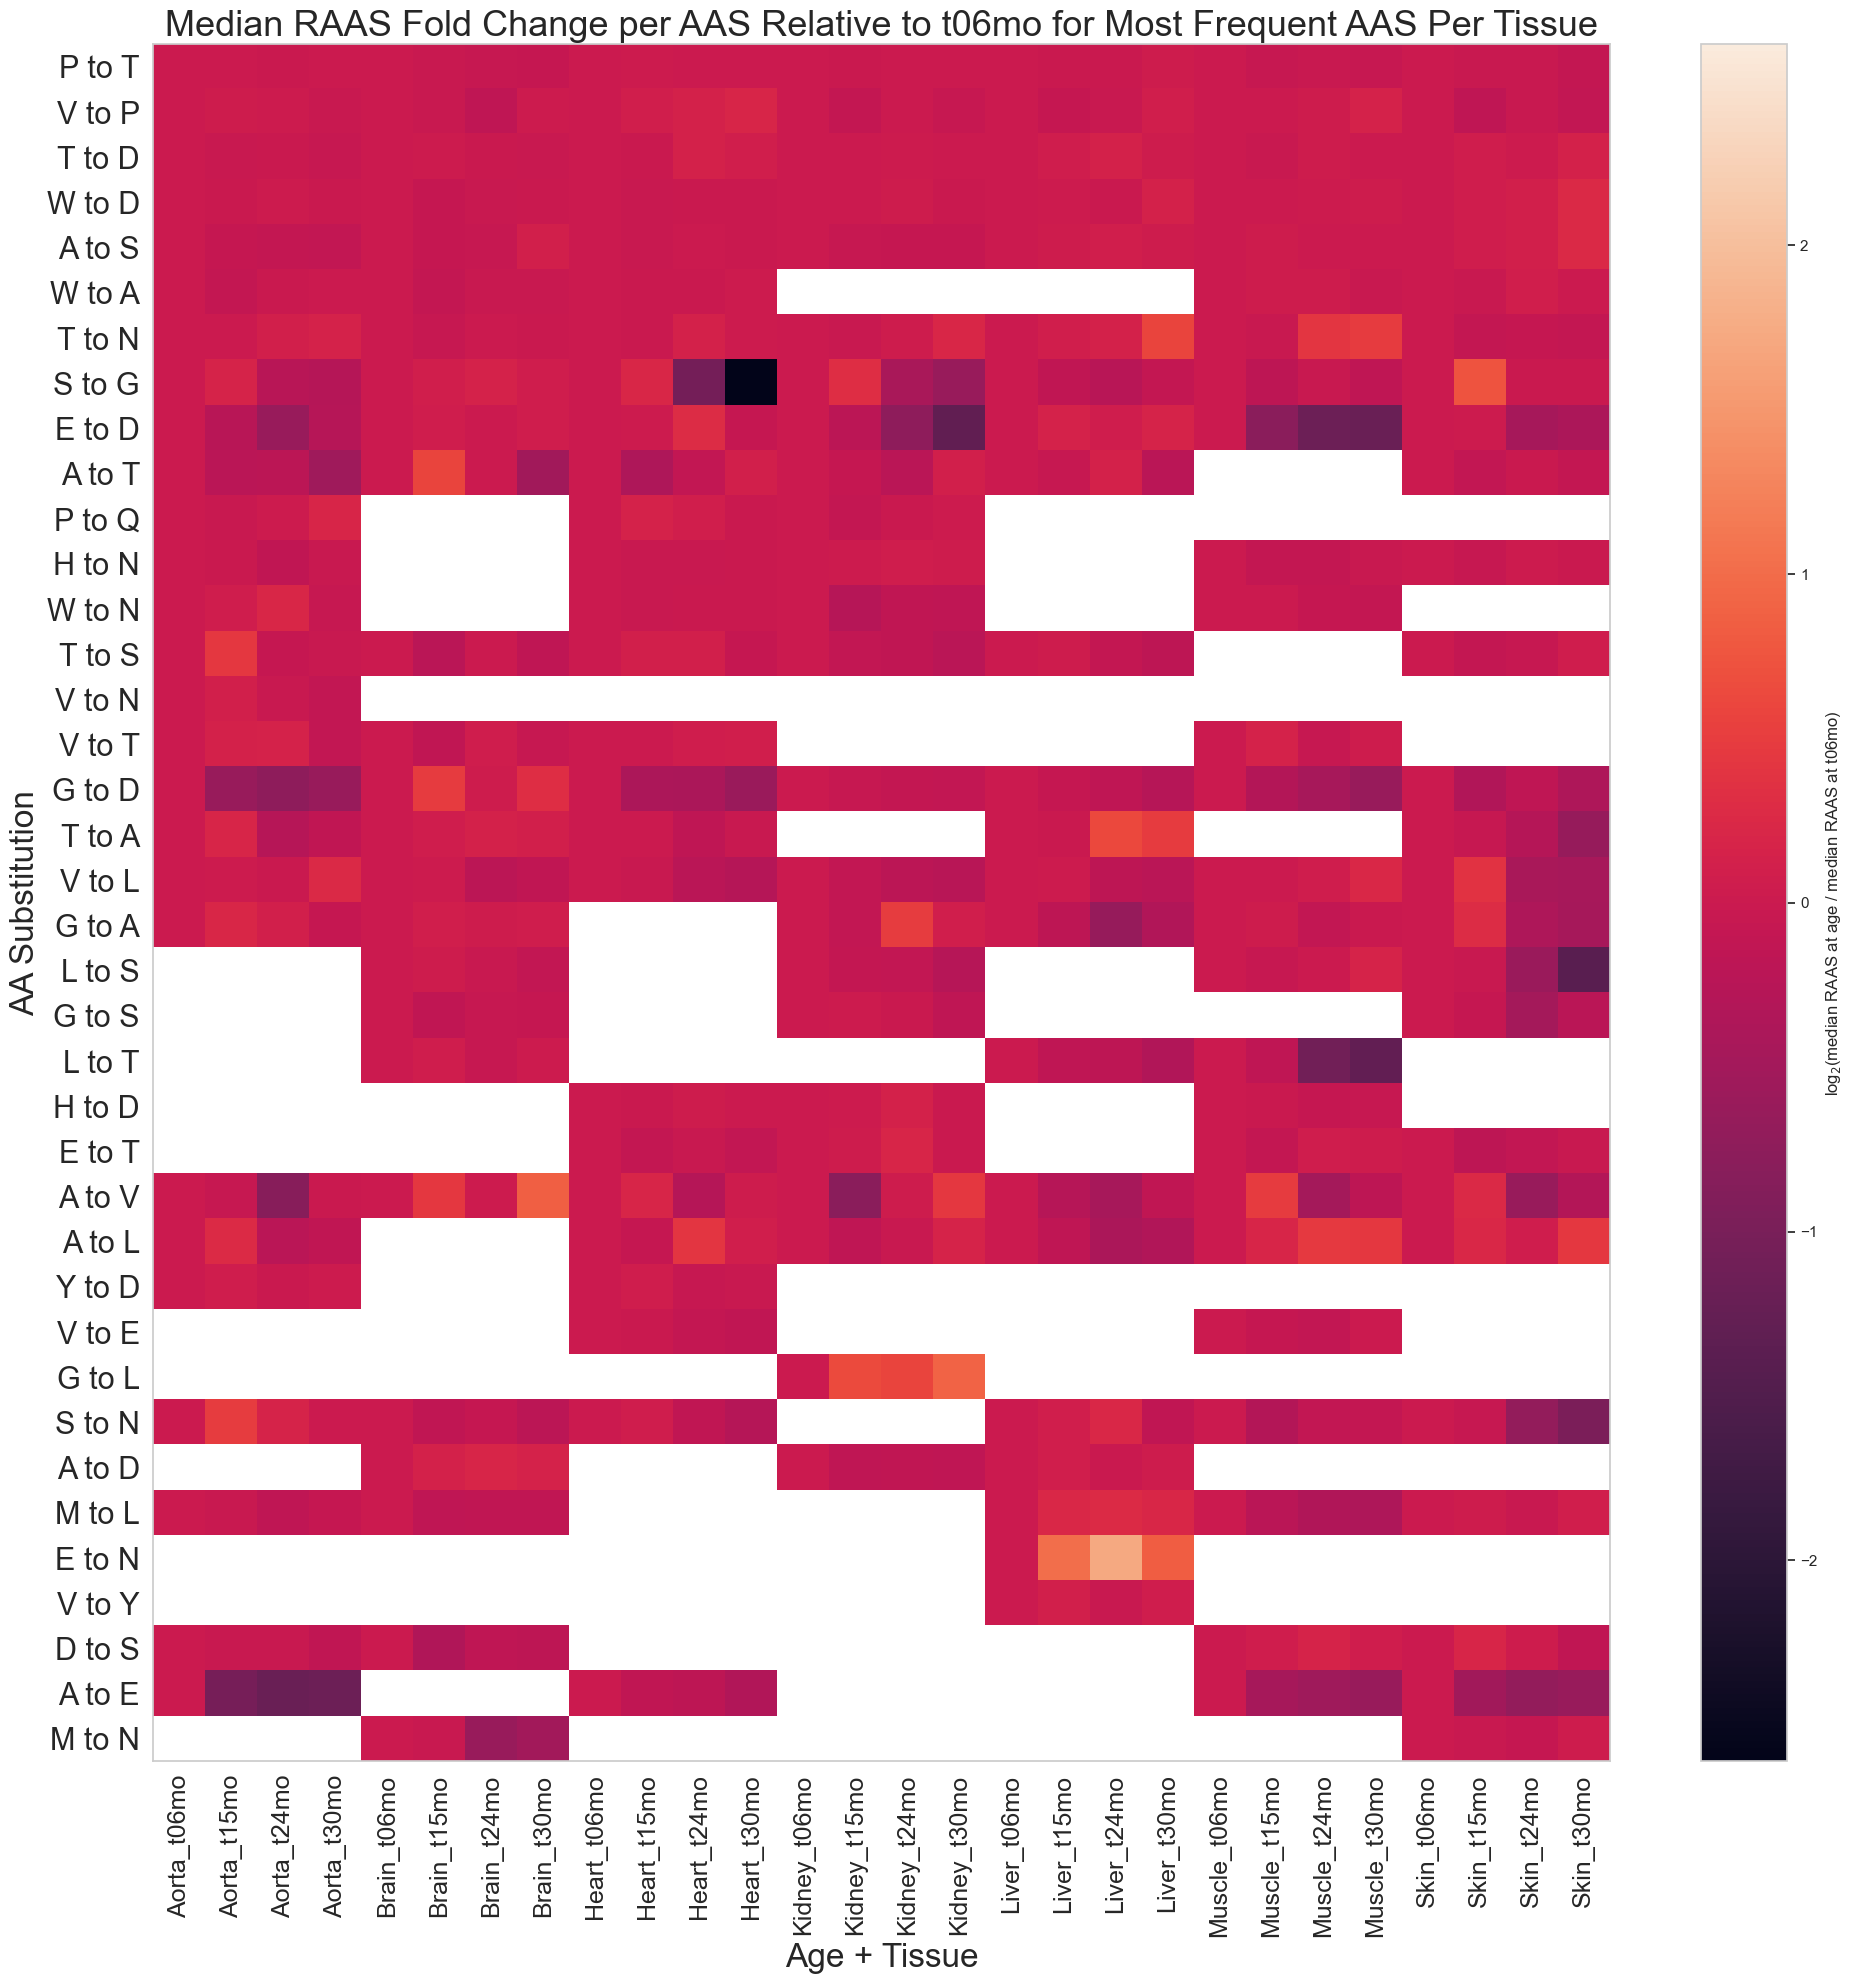

In [66]:
# Repeat the tissue comparison separately within each age group using log2 fold change relative to tissue-specific t06mo baselines.
ctrl_label='t06mo'
peptide_keys=['Dataset','MTP_seq','BP_seq','aa_sub']
sub_df=replicate_cols(SAAP_quant_df)
tissue_order=sorted(sub_df['Tissue'].dropna().unique())

top_subs=[]
for tissue in tissue_order: 
    tissue_top=(sub_df[sub_df['Tissue']==tissue][['MTP_seq','BP_seq','aa_sub']].drop_duplicates()['aa_sub'].value_counts().head(15).index.tolist())
    top_subs.extend(tissue_top)
top_subs=list(dict.fromkeys(top_subs))

plot_base_df=sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order=(plot_base_df['aa_sub'].value_counts().reindex(top_subs).dropna().index)
plot_base_df['log10_RAAS']=plot_base_df[raas_col]

saap_age_median_df=(plot_base_df.groupby(peptide_keys+['Age'],observed=False)['log10_RAAS'].median().reset_index().rename(columns={'log10_RAAS':'median_log10_RAAS'}))
ctrl_df=(saap_age_median_df[saap_age_median_df['Age']==ctrl_label][peptide_keys+['median_log10_RAAS']].rename(columns={'median_log10_RAAS':'median_log10_RAAS_t06mo'}))
norm_df=saap_age_median_df.merge(ctrl_df,on=peptide_keys,how='left')
norm_df['log2FC_vs_t06mo']=(norm_df['median_log10_RAAS']-norm_df['median_log10_RAAS_t06mo'])*np.log2(10)
norm_df=norm_df.dropna(subset=['log2FC_vs_t06mo']).copy()
norm_df['Tissue']=norm_df['Dataset']
norm_df['aa_sub']=pd.Categorical(norm_df['aa_sub'],categories=sub_order,ordered=True)
norm_df['Tissue']=pd.Categorical(norm_df['Tissue'],categories=tissue_order,ordered=True)
norm_df['Age']=pd.Categorical(norm_df['Age'],categories=age_order,ordered=True)

# aggregate log2FC via median
heatmap_df=(norm_df.groupby(['aa_sub','Age','Tissue'])['log2FC_vs_t06mo'].median().reset_index())
heatmap_df['Tissue_Age']=heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Age'].astype(str)

column_order=[]
for tissue in tissue_order:
    for age in age_order: column_order.append(tissue+'_'+age)

heatmap_matrix=(heatmap_df.pivot(index='aa_sub',columns='Tissue_Age',values='log2FC_vs_t06mo').reindex(index=sub_order).reindex(columns=column_order))
max_abs=np.nanmax(np.abs(heatmap_matrix.values))

# Plot heatmap of median log2FC relative to t06mo
plt.figure(figsize=(20,20))
plt.imshow(heatmap_matrix,aspect='auto',vmin=-max_abs,vmax=max_abs)
plt.colorbar(label=r'log$_2$(median RAAS at age / median RAAS at t06mo)')
plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=18)
plt.yticks(np.arange(len(heatmap_matrix.index)),heatmap_matrix.index,fontsize=22)
plt.xlabel('Age + Tissue',fontsize=24)
plt.ylabel('AA Substitution',fontsize=24)
plt.title('Median RAAS Fold Change per AAS Relative to t06mo for Most Frequent AAS Per Tissue',fontsize=26)
plt.tight_layout()
plt.grid(False)

plt.savefig(PLOT_DIR+'top_substitution_ReporterRAAS_age_tissue_heatmap.pdf',bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_44528/120038781.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df=(plot_df.groupby(['aa_sub','Tissue','Group'])['log2FC_vs_t06mo'].median().reset_index())


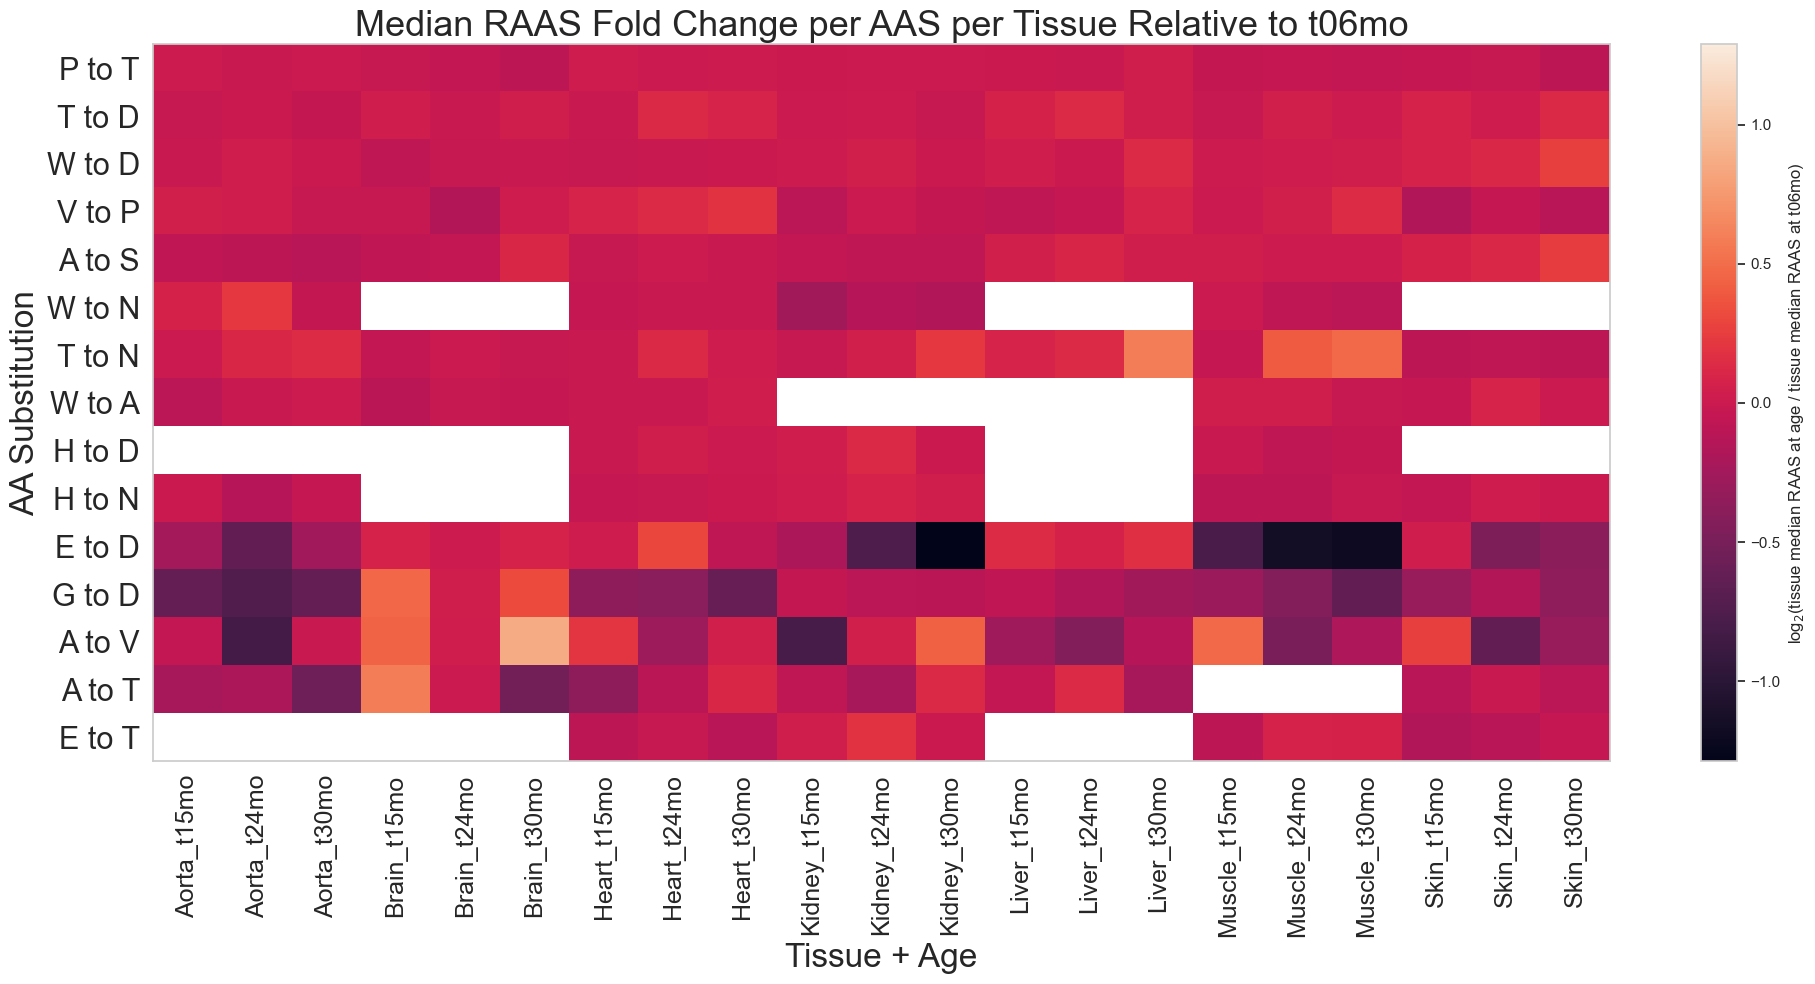

In [67]:
# Compute SAAP-level log2 fold change in median RAAS relative to each SAAP's t06mo baseline.
ctrl_label='t06mo'
plot_age_order=['t15mo','t24mo','t30mo']
peptide_keys=['Dataset','MTP_seq','BP_seq','aa_sub']
sub_df=replicate_cols(SAAP_quant_df)
sub_df['Group']=sub_df['Age']

# Reporter_RAAS is already log10 RAAS.
sub_df['log10_RAAS']=sub_df[raas_col]
sub_df=sub_df.replace([np.inf,-np.inf],np.nan).dropna(subset=['log10_RAAS'])
saap_age_median_df=(sub_df.groupby(peptide_keys+['Group'],observed=False)['log10_RAAS'].median().reset_index().rename(columns={'log10_RAAS':'median_log10_RAAS'}))
ctrl_df=(saap_age_median_df[saap_age_median_df['Group']==ctrl_label][peptide_keys+['median_log10_RAAS']].rename(columns={'median_log10_RAAS':'median_log10_RAAS_t06mo'}))
norm_df=saap_age_median_df.merge(ctrl_df,on=peptide_keys,how='left')
norm_df['log2FC_vs_t06mo']=(norm_df['median_log10_RAAS']-norm_df['median_log10_RAAS_t06mo'])*np.log2(10)
norm_df=norm_df.dropna(subset=['log2FC_vs_t06mo']).copy()
norm_df['Tissue']=norm_df['Dataset']
top_subs=(norm_df['aa_sub'].value_counts().head(15).index)

plot_df=norm_df[norm_df['aa_sub'].isin(top_subs)&norm_df['Group'].isin(plot_age_order)].copy()
sub_order=(plot_df['aa_sub'].value_counts().loc[top_subs].index)
tissue_order=sorted(plot_df['Tissue'].dropna().unique())
plot_df['aa_sub']=pd.Categorical(plot_df['aa_sub'],categories=sub_order,ordered=True)
plot_df['Group']=pd.Categorical(plot_df['Group'],categories=plot_age_order,ordered=True)
plot_df['Tissue']=pd.Categorical(plot_df['Tissue'],categories=tissue_order,ordered=True)

# aggregate log2FC via median
heatmap_df=(plot_df.groupby(['aa_sub','Tissue','Group'])['log2FC_vs_t06mo'].median().reset_index())
heatmap_df['Tissue_Age']=heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Group'].astype(str)

column_order=[]
for tissue in tissue_order:
    for age in plot_age_order: column_order.append(tissue+'_'+age)

heatmap_matrix=(heatmap_df.pivot(index='aa_sub',columns='Tissue_Age',values='log2FC_vs_t06mo').reindex(index=sub_order).reindex(columns=column_order))

# symmetric color scale around zero
max_abs=np.nanmax(np.abs(heatmap_matrix.values))

# Plot heatmap of median log2FC relative to t06mo
plt.figure(figsize=(20,10))
plt.imshow(heatmap_matrix,aspect='auto',vmin=-max_abs,vmax=max_abs)
plt.colorbar(label=r'log$_2$(tissue median RAAS at age / tissue median RAAS at t06mo)')
plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=18)
plt.yticks(np.arange(len(sub_order)),sub_order,fontsize=22)
plt.xlabel('Tissue + Age',fontsize=24)
plt.ylabel('AA Substitution',fontsize=24)
plt.title('Median RAAS Fold Change per AAS per Tissue Relative to t06mo',fontsize=26)
plt.tight_layout()
plt.grid(False)

plt.savefig(PLOT_DIR+'top15_substitution_log2_median_RAAS_over_t06mo_heatmap.pdf',bbox_inches='tight')
plt.show()